# Electricity market simulation result analysis (single-pass, reproducible)

This notebook streamlines scenario result post-processing for:
- **EOM** (day-ahead energy-only market)  
- **CRM_pos / CRM_neg** (aFRR capacity markets)

Key design principles:
1. **Single-pass I/O per scenario file** (chunked)  
2. **One configuration block** (scenarios, unit IDs, columns)  
3. **Robust time features** from `end_time` (no index-based quarters)  
4. **No seaborn dependency** (matplotlib only)  
5. **Cache outputs** (optional) to avoid re-reading multi-GB CSVs


In [73]:
# --- 0) Imports ---
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple, Optional
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## 1) Configuration (edit only this section)

In [74]:
# --- 1) Configuration ---

# A) Scenario files (label -> path to market_orders.csv)
SCENARIOS: Dict[str, str] = {
    "SE35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\2\\with_storage_trans\\market_orders.csv",
    "SEFE35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\4\\with_storage_trans\\market_orders.csv",
    "SEPH35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\5\\with_storage_trans\\market_orders.csv",
    "SEPE35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\6\\with_storage_trans\\market_orders.csv",
    "SEFES35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\10\\market_orders.csv",
    "SEPHS35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\11\\" + "market_orders.csv",
    "SEPES35": r"C:\\Users\\khm\\ownCloud (3)\\Dropbox\\Ph.D\\My publications\\Journal paper\\3\\Simulation\\Output\\12\\market_orders.csv",
}

# B) Scenario order for plots/tables (controls table/plot ordering)
SCENARIO_ORDER: List[str] = ['SE35', 'SEFE35', 'SEPH35', 'SEPE35', 'SEFES35', 'SEPHS35', 'SEPES35']

# C) Target unit IDs (cement-plant units)
TARGET_UNIT_IDS: List[str] = [
    "P100000124212", "P100000124839", "P100000125777", "P100000125790",
    "P100000125763", "P100000125764", "P100000125776", "P100000125770"
]

# D) Markets of interest
TARGET_MARKETS: List[str] = ["EOM", "CRM_pos", "CRM_neg"]          # for unit-level extraction
SYSTEM_MARKETS: List[str] = ["CRM_pos", "CRM_neg", "EOM"]          # for system aggregates

# E) Chunk size (tune to your RAM / SSD speed)
CHUNK_SIZE: int = 500_000

# F) Optional caching (recommended). If CACHE_DIR exists and contains cached parquet,
#    the notebook will load from cache instead of scanning raw CSVs again.
CACHE_DIR = Path("cache_market_analysis")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

USE_CACHE_IF_AVAILABLE: bool = True  # set to True to always use cache if available

print("Configured scenarios:", len(SCENARIOS))
print("Scenario order:", SCENARIO_ORDER)
print("Cache directory:", CACHE_DIR.resolve())


Configured scenarios: 7
Scenario order: ['SE35', 'SEFE35', 'SEPH35', 'SEPE35', 'SEFES35', 'SEPHS35', 'SEPES35']
Cache directory: C:\Manish_REPO\assume\examples\inputs\example_cement_plant_economics\cache_market_analysis


## 2) Utilities

In [75]:
# --- 2) Utilities ---

def _safe_usecols(csv_path: str | Path, requested: Iterable[str]) -> List[str]:
    """Return the subset of requested columns that actually exist in the CSV."""
    header = pd.read_csv(csv_path, nrows=0)
    available = set(header.columns)
    usecols = [c for c in requested if c in available]
    missing = [c for c in requested if c not in available]
    if missing:
        print(f"[WARN] {Path(csv_path).name}: missing columns ignored: {missing}")
    return usecols

def _to_num(s: pd.Series, abs_val: bool = False) -> pd.Series:
    out = pd.to_numeric(s, errors="coerce").fillna(0.0)
    return out.abs() if abs_val else out

def add_time_features(df: pd.DataFrame, time_col: str = "end_time") -> pd.DataFrame:
    """Adds robust time features based on a datetime column."""
    if time_col not in df.columns:
        return df
    if not np.issubdtype(df[time_col].dtype, np.datetime64):
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    dt = df[time_col]
    df["hour"] = dt.dt.hour
    df["month"] = dt.dt.month
    df["quarter"] = dt.dt.quarter  # 1..4
    # Meteorological seasons (DJF/MAM/JJA/SON)
    df["season"] = pd.cut(
        df["month"],
        bins=[0, 2, 5, 8, 11, 12],
        labels=["Winter", "Spring", "Summer", "Autumn", "Winter"],
        include_lowest=True,
        right=True,
    )
    return df

@dataclass
class RunningAgg:
    # For VWAP: sum(|vol|*price) / sum(|vol|)
    vol_sum: float = 0.0
    rev_sum: float = 0.0
    # For mean/min/max (unweighted): sum(price)/count, min(price), max(price)
    price_sum: float = 0.0
    price_count: int = 0
    price_min: float = np.inf
    price_max: float = -np.inf

    def update(self, price: pd.Series, vol: pd.Series):
        vol = _to_num(vol, abs_val=True)
        price = _to_num(price, abs_val=False)

        self.vol_sum += float(vol.sum())
        self.rev_sum += float((vol * price).sum())

        # unweighted stats
        self.price_sum += float(price.sum())
        self.price_count += int(price.shape[0])
        if price.shape[0] > 0:
            self.price_min = float(min(self.price_min, float(price.min())))
            self.price_max = float(max(self.price_max, float(price.max())))

    def vwap(self) -> float:
        return self.rev_sum / self.vol_sum if self.vol_sum > 0 else 0.0

    def mean(self) -> float:
        return self.price_sum / self.price_count if self.price_count > 0 else 0.0

    def min(self) -> float:
        return 0.0 if self.price_min == np.inf else self.price_min

    def max(self) -> float:
        return 0.0 if self.price_max == -np.inf else self.price_max


## 3) Single-pass extraction (unit-level + system-level)

In [76]:
# --- 3) Single-pass extraction (robust dtypes + deterministic aggregates) ---

# Common NA tokens found in exported CSVs
NA_TOKENS = ["", "NA", "N/A", "null", "None", "-", "nan", "NaN", "inf", "-inf"]

# Deterministic dtype map (prevents mixed-type warnings)
# Read numeric-like columns as string first; coerce safely after read
DTYPE_MAP = {
    # identifiers / labels
    "bid_id": "string",
    "bid_type": "string",
    "market_id": "string",
    "node": "string",
    "simulation": "string",
    "unit_id": "string",

    # times
    "start_time": "string",
    "end_time": "string",

    # numeric-ish columns: read as string to avoid parse-time crashes
    "accepted_price": "string",
    "accepted_volume": "string",
    "price": "string",
    "volume": "string",
    "max_power": "string",
    "min_power": "string",
}

NUMERIC_COLS = ["accepted_price", "accepted_volume", "price", "volume", "max_power", "min_power"]

def _safe_usecols(csv_path: str, requested_cols: List[str]) -> List[str]:
    """
    Returns only those columns that exist in the CSV header.
    """
    header = pd.read_csv(csv_path, nrows=0).columns.tolist()
    available = [c for c in requested_cols if c in header]
    missing = [c for c in requested_cols if c not in header]
    if missing:
        print(f"    [WARN] Missing columns in {Path(csv_path).name}: {missing}")
    return available


class RunningAgg:
    """
    Streaming aggregator for accepted_price stats and VWAP using |accepted_volume| as weights.
    """
    def __init__(self) -> None:
        self.vol_sum = 0.0
        self.pw_sum = 0.0
        self.price_sum = 0.0
        self.price_count = 0
        self.p_min = np.inf
        self.p_max = -np.inf

    def update(self, price: pd.Series, volume: pd.Series) -> None:
        # Coerce safe numeric
        p = pd.to_numeric(price, errors="coerce")
        v = pd.to_numeric(volume, errors="coerce").abs()

        SENTINEL_PRICES = {-9999.0, -999.0}
        mask = p.notna() & v.notna() & (v > 0) & (~p.isin(SENTINEL_PRICES))

        if not mask.any():
            return

        p = p[mask]
        v = v[mask]

        self.vol_sum += float(v.sum())
        self.pw_sum += float((p * v).sum())

        self.price_sum += float(p.sum())
        self.price_count += int(p.shape[0])

        pmin = float(p.min())
        pmax = float(p.max())
        if pmin < self.p_min:
            self.p_min = pmin
        if pmax > self.p_max:
            self.p_max = pmax

    def vwap(self) -> float:
        return float(self.pw_sum / self.vol_sum) if self.vol_sum > 0 else np.nan

    def mean(self) -> float:
        return float(self.price_sum / self.price_count) if self.price_count > 0 else np.nan

    def min(self) -> float:
        return float(self.p_min) if np.isfinite(self.p_min) else np.nan

    def max(self) -> float:
        return float(self.p_max) if np.isfinite(self.p_max) else np.nan


def run_single_pass(
    scenarios: Dict[str, str],
    target_units: List[str],
    target_markets: List[str],
    system_markets: List[str],
    chunk_size: int,
    cache_dir: Path,
    scenario_order: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      - unit_extract: all rows for target units in target_markets (e.g., EOM/CRM_pos/CRM_neg)
      - system_market_agg: scenario x market aggregates (VWAP, mean/min/max, totals)
      - system_quarter_agg: scenario x market x quarter aggregates (for seasonal plots)
      - eom_full_price_stats: optional scenario-level EOM stats (kept for compatibility; empty if not computed)
    """
    scenario_order = scenario_order or list(scenarios.keys())

    cache_dir.mkdir(parents=True, exist_ok=True)
    unit_parquet = cache_dir / "unit_extract.parquet"
    sys_parquet  = cache_dir / "system_market_agg.parquet"
    qtr_parquet  = cache_dir / "system_quarter_agg.parquet"

    if USE_CACHE_IF_AVAILABLE and unit_parquet.exists() and sys_parquet.exists() and qtr_parquet.exists():
        print("[CACHE] Loading cached outputs...")
        unit_extract = pd.read_parquet(unit_parquet)
        system_market_agg = pd.read_parquet(sys_parquet)
        system_quarter_agg = pd.read_parquet(qtr_parquet)
        return unit_extract, system_market_agg, system_quarter_agg, pd.DataFrame()

    print("[SCAN] Building outputs from raw CSVs (single pass per scenario)...")

    requested_cols = [
        "start_time", "end_time", "market_id",
        "unit_id", "bid_id", "bid_type", "node",
        "volume", "accepted_volume", "price", "accepted_price",
        "simulation", "max_power", "min_power"
    ]

    unit_rows: List[pd.DataFrame] = []

    sys_aggs: Dict[Tuple[str, str], RunningAgg] = {}
    qtr_aggs: Dict[Tuple[str, str, int], RunningAgg] = {}

    # Precompute sets for faster isin
    target_units_set = set(map(str, target_units))
    target_markets_set = set(map(str, target_markets))
    system_markets_set = set(map(str, system_markets))

    for scen, csv_path in scenarios.items():
        csv_path = str(csv_path)
        print(f"  -> {scen}: {csv_path}")

        usecols = _safe_usecols(csv_path, requested_cols)
        if "market_id" not in usecols:
            print(f"    [SKIP] {scen}: 'market_id' not present.")
            continue

        # Build dtype dict only for columns we actually read
        dtype = {c: DTYPE_MAP[c] for c in usecols if c in DTYPE_MAP}

        for chunk in pd.read_csv(
            csv_path,
            usecols=usecols,
            chunksize=chunk_size,
            dtype=dtype,                # numeric fields read as string
            na_values=NA_TOKENS,
            keep_default_na=True,
            low_memory=False,           # reduces dtype fragmentation across chunks
        ):
            # Coerce numeric columns safely (bad tokens -> NaN)
            for col in NUMERIC_COLS:
                if col in chunk.columns:
                    chunk[col] = pd.to_numeric(chunk[col].str.replace(",", ".", regex=False), errors="coerce")

            # --- Unit-level extraction (target units + target markets) ---
            if "unit_id" in chunk.columns:
                # ensure string comparison
                unit_col = chunk["unit_id"].astype("string")
                market_col = chunk["market_id"].astype("string")

                m_unit = market_col.isin(target_markets_set) & unit_col.isin(target_units_set)
                if m_unit.any():
                    u = chunk.loc[m_unit].copy()
                    u["scenario_label"] = scen
                    unit_rows.append(u)

            # --- System-level aggregates (selected markets, all units) ---
            market_col = chunk["market_id"].astype("string")
            m_sys = market_col.isin(system_markets_set)
            if not m_sys.any():
                continue

            # Need accepted_price + accepted_volume for VWAP etc.
            if "accepted_price" not in chunk.columns or "accepted_volume" not in chunk.columns:
                continue

            s = chunk.loc[m_sys, ["market_id", "accepted_price", "accepted_volume"] + (["end_time"] if "end_time" in chunk.columns else [])].copy()

            # Quarterly derivation from end_time (robust)
            if "end_time" in s.columns:
                s["end_time"] = pd.to_datetime(s["end_time"], errors="coerce", utc=False)
                s["quarter"] = s["end_time"].dt.quarter

            # Aggregate per market (and per quarter)
            for market, g in s.groupby("market_id", sort=False):
                key = (scen, str(market))
                sys_aggs.setdefault(key, RunningAgg()).update(g["accepted_price"], g["accepted_volume"])

                if "quarter" in g.columns:
                    gq_valid = g[g["quarter"].notna()]
                    if not gq_valid.empty:
                        for q, gq in gq_valid.groupby("quarter", sort=False):
                            qkey = (scen, str(market), int(q))
                            qtr_aggs.setdefault(qkey, RunningAgg()).update(gq["accepted_price"], gq["accepted_volume"])

    # ---- Build unit_extract ----
    unit_extract = pd.concat(unit_rows, ignore_index=True) if unit_rows else pd.DataFrame()
    if not unit_extract.empty and "end_time" in unit_extract.columns:
        unit_extract["end_time"] = pd.to_datetime(unit_extract["end_time"], errors="coerce", utc=False)

    # ---- Build system_market_agg ----
    rows = []
    for (scen, market), agg in sys_aggs.items():
        rows.append({
            "scenario_label": scen,
            "market_id": market,
            "accepted_volume_abs_sum": agg.vol_sum,
            "vwap_accepted_price": agg.vwap(),
            "accepted_price_mean": agg.mean(),
            "accepted_price_min": agg.min(),
            "accepted_price_max": agg.max(),
            "n_rows": agg.price_count,
        })
    system_market_agg = pd.DataFrame(rows)

    # ---- Build system_quarter_agg ----
    qrows = []
    for (scen, market, q), agg in qtr_aggs.items():
        qrows.append({
            "scenario_label": scen,
            "market_id": market,
            "quarter": q,
            "accepted_volume_abs_sum": agg.vol_sum,
            "vwap_accepted_price": agg.vwap(),
            "accepted_price_mean": agg.mean(),
            "accepted_price_min": agg.min(),
            "accepted_price_max": agg.max(),
            "n_rows": agg.price_count,
        })
    system_quarter_agg = pd.DataFrame(qrows)

    # ---- Ensure ordering ----
    if not system_market_agg.empty:
        system_market_agg["scenario_label"] = pd.Categorical(
            system_market_agg["scenario_label"],
            categories=scenario_order,
            ordered=True
        )
        system_market_agg = system_market_agg.sort_values(["scenario_label", "market_id"]).reset_index(drop=True)

    if not system_quarter_agg.empty:
        system_quarter_agg["scenario_label"] = pd.Categorical(
            system_quarter_agg["scenario_label"],
            categories=scenario_order,
            ordered=True
        )
        system_quarter_agg = system_quarter_agg.sort_values(["scenario_label", "market_id", "quarter"]).reset_index(drop=True)

    # ---- Cache outputs ----
    unit_extract.to_parquet(unit_parquet, index=False)
    system_market_agg.to_parquet(sys_parquet, index=False)
    system_quarter_agg.to_parquet(qtr_parquet, index=False)

    print("[DONE] Cached:")
    print("  ", unit_parquet)
    print("  ", sys_parquet)
    print("  ", qtr_parquet)

    # Kept for interface compatibility (not computed here)
    eom_full_price_stats = pd.DataFrame()

    return unit_extract, system_market_agg, system_quarter_agg, eom_full_price_stats


# --- Preflight: ensure scenario files exist ---
missing_files = {k: v for k, v in SCENARIOS.items() if not Path(v).exists()}
if missing_files:
    msg = "\n".join([f"  - {k}: {v}" for k, v in missing_files.items()])
    raise FileNotFoundError(
        "Some scenario CSV paths do not exist on this machine. Update SCENARIOS in Section 1.\n" + msg
    )

# --- Execute extraction ---
unit_extract, system_market_agg, system_quarter_agg, _ = run_single_pass(
    scenarios=SCENARIOS,
    target_units=TARGET_UNIT_IDS,
    target_markets=TARGET_MARKETS,
    system_markets=SYSTEM_MARKETS,
    chunk_size=CHUNK_SIZE,
    cache_dir=CACHE_DIR,
    scenario_order=SCENARIO_ORDER,
)

print("unit_extract rows:", len(unit_extract))
display(system_market_agg.head(10))


[CACHE] Loading cached outputs...
unit_extract rows: 592656


,scenario_label,market_id,accepted_volume_abs_sum,vwap_accepted_price,accepted_price_mean,accepted_price_min,accepted_price_max,n_rows
0,SE35,CRM_neg,1.133640e+07,38.880667,17.714627,-6682.9,795.65,43451
1,SE35,CRM_pos,1.194564e+07,90.393200,8.496629,0.0,2923.00,143020
2,SE35,EOM,1.690596e+09,21.302079,29.383483,0.0,287.14,17026077
3,SEFE35,CRM_neg,1.170629e+07,21.293920,11.723730,-4941.4,795.65,39489
4,SEFE35,CRM_pos,1.199992e+07,32.236937,3.263155,0.0,1506.30,140954
5,SEFE35,EOM,1.690585e+09,26.756578,39.007661,0.0,294.24,15499192
6,SEPH35,CRM_neg,1.171492e+07,19.608060,11.128110,-2642.1,795.65,38651
7,SEPH35,CRM_pos,1.200458e+07,32.901421,3.315322,0.0,2168.00,141016
8,SEPH35,EOM,1.672417e+09,25.903176,37.793351,0.0,294.37,15409479
9,SEPE35,CRM_neg,1.167295e+07,20.036747,11.127368,-8175.6,795.65,39014


In [77]:
csv_path = SCENARIOS["SE35"]  # pick one scenario
bad_found = 0

usecols = ["market_id","accepted_price","accepted_volume"]
for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=2_000_000, dtype="string", low_memory=False):
    chunk["accepted_price"] = pd.to_numeric(chunk["accepted_price"], errors="coerce")
    chunk["accepted_volume"] = pd.to_numeric(chunk["accepted_volume"], errors="coerce")

    m = (chunk["market_id"] == "CRM_neg") & (chunk["accepted_price"] == -9999)
    if m.any():
        print(chunk.loc[m, ["accepted_price","accepted_volume"]].head(20))
        bad_found += m.sum()
        break

print("found_rows_in_first_hit:", bad_found)


         accepted_price  accepted_volume
1849625         -9999.0           5.9305
found_rows_in_first_hit: 1


In [78]:
# System-level: check how many sentinel prices exist by scenario/market
sys = pd.read_parquet(r"cache_market_analysis\system_market_agg.parquet")
unit = pd.read_parquet(r"cache_market_analysis\unit_extract.parquet")

# If you have the raw cached system_quarter_agg, skip; otherwise focus on unit extract:
sent = unit[(unit["accepted_price"] == -9999) & unit["market_id"].isin(["CRM_pos","CRM_neg"])]
sent.groupby(["scenario_label","market_id"]).size().sort_values(ascending=False).head(20)


Series([], dtype: int64)

In [79]:
tmp = unit[unit["market_id"].isin(["CRM_pos","CRM_neg"])].copy()
tmp["accepted_volume"] = pd.to_numeric(tmp["accepted_volume"], errors="coerce")
tmp["accepted_price"] = pd.to_numeric(tmp["accepted_price"], errors="coerce")

tmp.groupby(["scenario_label","market_id"]).agg(
    n=("accepted_volume","size"),
    n_acc_zero=("accepted_volume", lambda x: (x==0).sum()),
    n_acc_nan=("accepted_volume", lambda x: x.isna().sum()),
    n_price_nan=("accepted_price", lambda x: x.isna().sum()),
)


n  n_acc_zero  n_acc_nan  n_price_nan
scenario_label market_id                                           
SEFE35         CRM_neg     1846       953.0        0.0          0.0
               CRM_pos    15578     12265.0        0.0          0.0
SEFES35        CRM_neg     1387       752.0        0.0          0.0
               CRM_pos    16085     12562.0        0.0          0.0
SEPE35         CRM_neg     1387       707.0        0.0          0.0
               CRM_pos    16085     12598.0        0.0          0.0
SEPES35        CRM_neg     1366       753.0        0.0          0.0
               CRM_pos    16106     11819.0        0.0          0.0
SEPH35         CRM_neg     1854      1044.0        0.0          0.0
               CRM_pos    15618     12256.0        0.0          0.0
SEPHS35        CRM_neg      866       395.0        0.0          0.0
               CRM_pos    16606     11191.0        0.0          0.0

In [80]:
# 1) Confirm system_market_agg no longer has the -9999 min
system_market_agg.loc[
    system_market_agg["accepted_price_min"] == -9999,
    ["scenario_label", "market_id", "accepted_price_min"]
]


,scenario_label,market_id,accepted_price_min


## 4) CRM_pos / CRM_neg: unit-level KPIs (success rate, revenue)

In [81]:
# --- 4) Unit-level CRM KPIs ---

if unit_extract.empty:
    raise RuntimeError("unit_extract is empty. Check SCENARIOS paths and that target units/markets exist in the CSVs.")

crm_units = unit_extract[unit_extract["market_id"].isin(["CRM_pos", "CRM_neg"])].copy()

# numeric safety
for c in ["volume", "accepted_volume", "accepted_price"]:
    if c in crm_units.columns:
        crm_units[c] = _to_num(crm_units[c], abs_val=(c in ["volume", "accepted_volume"]))

# success rate & revenue
crm_units["revenue"] = crm_units["accepted_volume"] * crm_units["accepted_price"]

unit_kpis = (crm_units
    .groupby(["scenario_label", "market_id", "unit_id"], as_index=False)
    .agg(offered_volume=("volume", "sum"),
         accepted_volume=("accepted_volume", "sum"),
         revenue=("revenue", "sum"))
)
unit_kpis["success_rate_pct"] = np.where(
    unit_kpis["offered_volume"] > 0,
    100 * unit_kpis["accepted_volume"] / unit_kpis["offered_volume"],
    0.0
)

display(unit_kpis.head(10))

# Pivot tables (paper-friendly)
success_pivot = unit_kpis.pivot_table(index="unit_id", columns=["market_id", "scenario_label"], values="success_rate_pct")
revenue_pivot = unit_kpis.pivot_table(index="unit_id", columns=["market_id", "scenario_label"], values="revenue")

print("Success rate (%) pivot (rows=units, cols=market/scenario):")
display(success_pivot.round(2))

print("Revenue pivot (rows=units, cols=market/scenario):")
display(revenue_pivot.style.format("{:,.2f}"))


,scenario_label,market_id,unit_id,offered_volume,accepted_volume,revenue,success_rate_pct
0,SEFE35,CRM_neg,P100000124212,46265.0,22590.68,2256997.9392,48.828877
1,SEFE35,CRM_neg,P100000124839,44392.0,21422.25,2176392.95192,48.257006
2,SEFE35,CRM_neg,P100000125763,25580.0,12100.796,1172312.30736,47.305692
3,SEFE35,CRM_neg,P100000125764,23093.0,11270.0,1154992.92,48.802667
4,SEFE35,CRM_neg,P100000125770,20696.0,10160.0,1038471.12,49.091612
5,SEFE35,CRM_neg,P100000125776,23093.0,11267.2556,1139794.353776,48.790783
6,SEFE35,CRM_neg,P100000125777,28732.0,14222.0,1442250.12,49.498817
7,SEFE35,CRM_neg,P100000125790,27914.0,13405.944,1277998.28352,48.025879
8,SEFE35,CRM_pos,P100000124212,615256.0,100741.1788,2609230.453112,16.373864
9,SEFE35,CRM_pos,P100000124839,585202.0,95259.3634,2413187.982068,16.278031


Success rate (%) pivot (rows=units, cols=market/scenario):


market_id      CRM_neg                                       CRM_pos                                      
scenario_label  SEFE35 SEFES35 SEPE35 SEPES35 SEPH35 SEPHS35  SEFE35 SEFES35 SEPE35 SEPES35 SEPH35 SEPHS35
unit_id                                                                                                   
P100000124212    48.83   54.32  55.54   45.58  43.75   57.72   16.37   18.26  16.25   21.78  16.67   30.11
P100000124839    48.26   53.31  54.86   45.69  42.59   57.47   16.28   16.57  17.56   21.33  15.45   30.02
P100000125763    47.31   52.64  56.38   45.81  43.27   57.70   16.25   17.96  16.41   21.32  17.44   30.86
P100000125764    48.80   52.93  54.98   46.06  43.87   57.58   16.23   17.11  17.50   21.40  17.61   30.95
P100000125770    49.09   53.05  56.29   46.21  44.80   57.14   17.01   17.86  17.21   22.41  16.90   31.45
P100000125776    48.79   52.93  54.32   47.09  43.87   57.58   16.89   17.22  17.63   21.07  17.79   30.41
P100000125777    49.50   52.68  55.20   46.17  44.32   59.41   15.78   18.10  18.48   21.21  16.54   30.57
P100000125790    48.03   53.45  54.28   45.54  43.94   56.48   17.51   17.39  18.23   21.21  16.30   30.96

Revenue pivot (rows=units, cols=market/scenario):


## 5) CRM hourly price heatmaps (matplotlib)

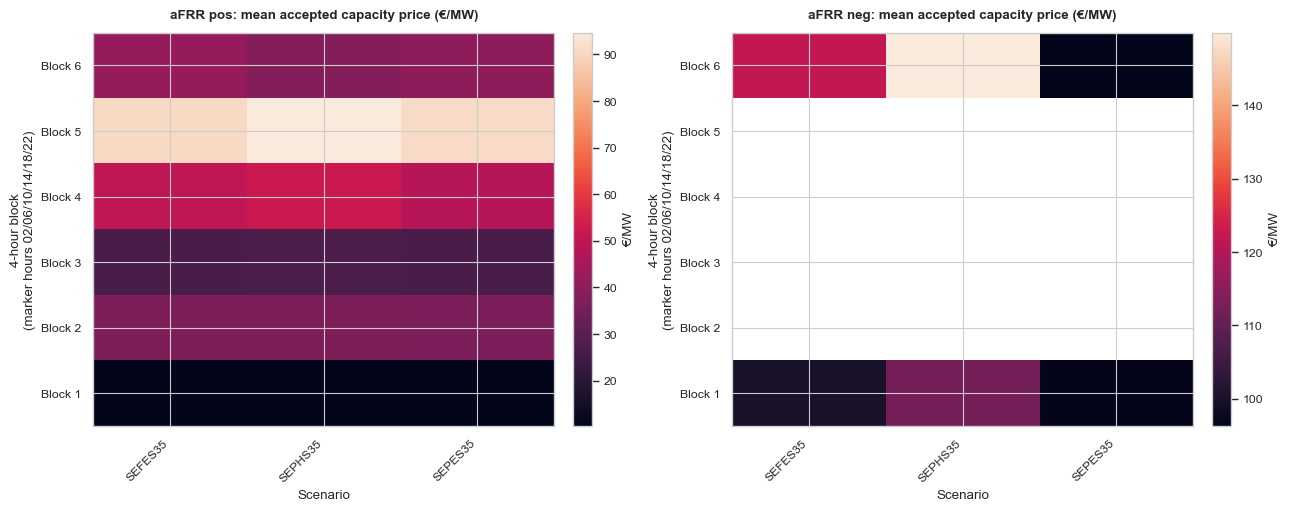

In [82]:
# --- Side-by-side CRM block heatmaps for selected scenarios (target units) ---

SELECTED_SCENARIOS = ["SEFES35", "SEPHS35", "SEPES35"]
MARKER_HOURS = [2, 6, 10, 14, 18, 22]  # block marker hours
HOUR_TO_BLOCK = {h: i + 1 for i, h in enumerate(MARKER_HOURS)}


def _prep_block_pivot(df: pd.DataFrame, market_id: str, scenarios: list) -> pd.DataFrame:
    d = df[df["market_id"] == market_id].copy()
    if d.empty:
        return pd.DataFrame()

    # numeric + accepted only
    d["accepted_price"] = pd.to_numeric(d["accepted_price"], errors="coerce")
    d["accepted_volume"] = pd.to_numeric(d["accepted_volume"], errors="coerce")
    d = d[d["accepted_price"].notna() & (d["accepted_volume"].abs() > 0)]
    if d.empty:
        return pd.DataFrame()

    # scenario filter
    d = d[d["scenario_label"].isin(scenarios)]
    if d.empty:
        return pd.DataFrame()

    # block mapping
    d["end_time"] = pd.to_datetime(d["end_time"], errors="coerce")
    d = d[d["end_time"].notna()]
    d["hour"] = d["end_time"].dt.hour
    d = d[d["hour"].isin(MARKER_HOURS)]
    if d.empty:
        return pd.DataFrame()

    d["block"] = d["hour"].map(HOUR_TO_BLOCK)

    pivot = (
        d.pivot_table(index="block", columns="scenario_label", values="accepted_price", aggfunc="mean")
        .reindex(index=range(1, 7), columns=scenarios)
    )
    return pivot


def plot_side_by_side_crm_blocks(df: pd.DataFrame, scenarios: list):
    piv_pos = _prep_block_pivot(df, "CRM_pos", scenarios)
    piv_neg = _prep_block_pivot(df, "CRM_neg", scenarios)

    if piv_pos.empty and piv_neg.empty:
        print("[INFO] No accepted CRM_pos/CRM_neg rows for the selected scenarios.")
        return

    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=(1.6 * max(4, len(scenarios)) * 2, 5),
        constrained_layout=True
    )

    # Helper for one panel
    def _plot_panel(ax, pivot, title):
        if pivot.empty:
            ax.set_title(title, fontweight="bold")
            ax.axis("off")
            ax.text(0.5, 0.5, "No accepted data", ha="center", va="center")
            return None

        Z = pivot.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
        im = ax.imshow(Z, aspect="auto", origin="lower")

        ax.set_title(title, fontweight="bold", pad=10)
        ax.set_xlabel("Scenario")
        ax.set_ylabel("4-hour block\n(marker hours 02/06/10/14/18/22)")

        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=45, ha="right")

        ax.set_yticks(np.arange(6))
        ax.set_yticklabels([f"Block {i}" for i in range(1, 7)])

        return im

    im1 = _plot_panel(axes[0], piv_pos, "aFRR pos: mean accepted capacity price (€/MW)")
    im2 = _plot_panel(axes[1], piv_neg, "aFRR neg: mean accepted capacity price (€/MW)")

    # Separate colorbars (safer because CRM_pos and CRM_neg ranges can differ)
    if im1 is not None:
        cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
        cbar1.set_label("€/MW")
    if im2 is not None:
        cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
        cbar2.set_label("€/MW")

    plt.show()


plot_side_by_side_crm_blocks(crm_units, SELECTED_SCENARIOS)


## 6) CRM: system-wide VWAP and weekly capacity price comparison

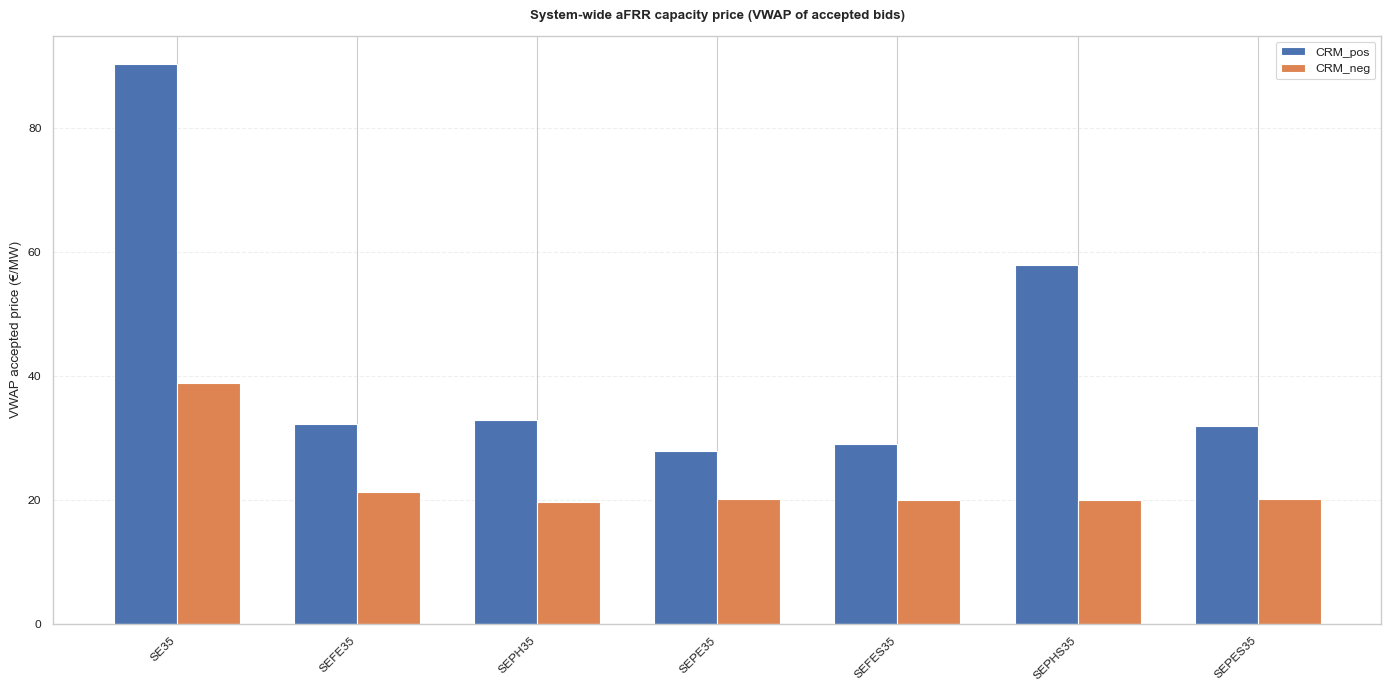

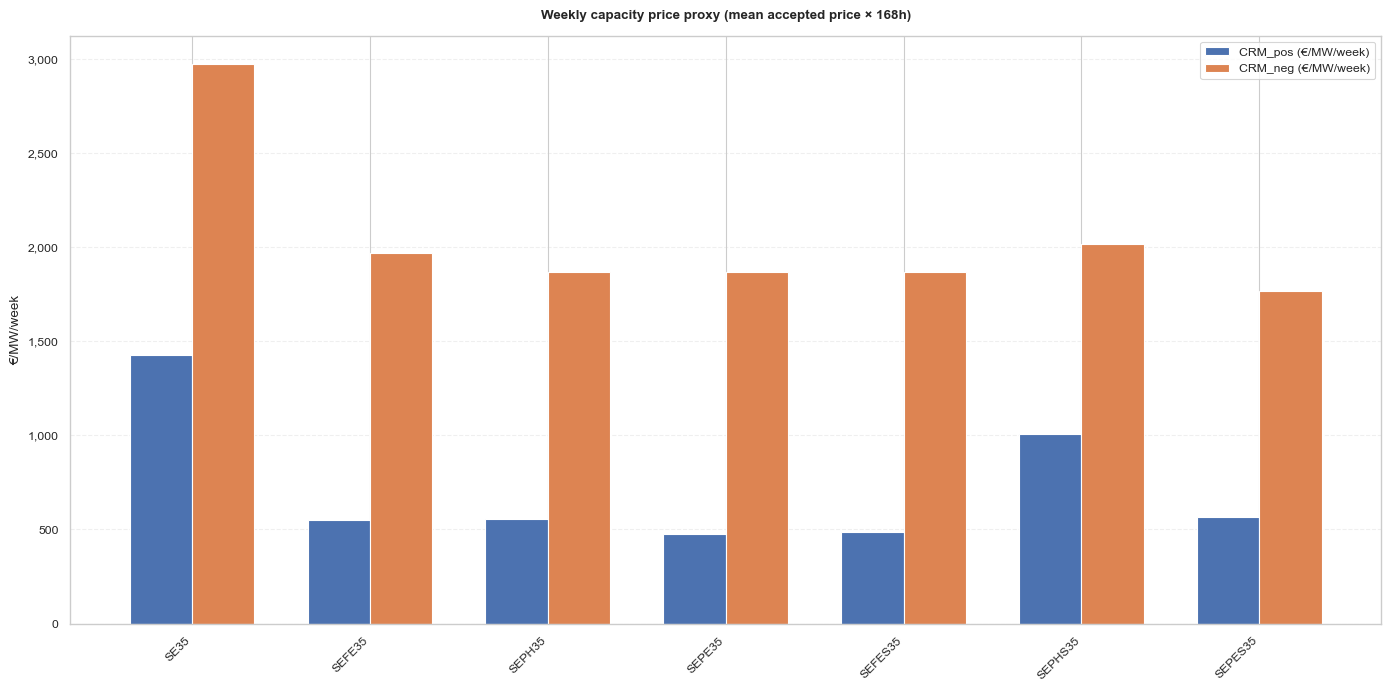

In [83]:
# --- 6) System-wide CRM VWAP and weekly price ---

crm_sys = system_market_agg[system_market_agg["market_id"].isin(["CRM_pos", "CRM_neg"])].copy()
if crm_sys.empty:
    print("[INFO] system_market_agg has no CRM rows (CRM_pos/CRM_neg).")
else:
    # VWAP bar plot
    pivot_vwap = crm_sys.pivot(index="scenario_label", columns="market_id", values="vwap_accepted_price").reindex(SCENARIO_ORDER)

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(pivot_vwap.index))
    width = 0.35

    ax.bar(x - width/2, pivot_vwap.get("CRM_pos", pd.Series(0, index=pivot_vwap.index)), width, label="CRM_pos")
    ax.bar(x + width/2, pivot_vwap.get("CRM_neg", pd.Series(0, index=pivot_vwap.index)), width, label="CRM_neg")

    ax.set_title("System-wide aFRR capacity price (VWAP of accepted bids)", pad=12, fontweight="bold")
    ax.set_ylabel("VWAP accepted price (€/MW)")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_vwap.index, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Weekly price approximation (mean hourly price * 168)
    pivot_week = crm_sys.pivot(index="scenario_label", columns="market_id", values="accepted_price_mean").reindex(SCENARIO_ORDER) * 168

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(pivot_week.index))
    width = 0.35

    ax.bar(x - width/2, pivot_week.get("CRM_pos", pd.Series(0, index=pivot_week.index)), width, label="CRM_pos (€/MW/week)")
    ax.bar(x + width/2, pivot_week.get("CRM_neg", pd.Series(0, index=pivot_week.index)), width, label="CRM_neg (€/MW/week)")

    ax.set_title("Weekly capacity price proxy (mean accepted price × 168h)", pad=12, fontweight="bold")
    ax.set_ylabel("€/MW/week")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_week.index, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7) CRM: seasonal / quarterly comparison (robust time-based)

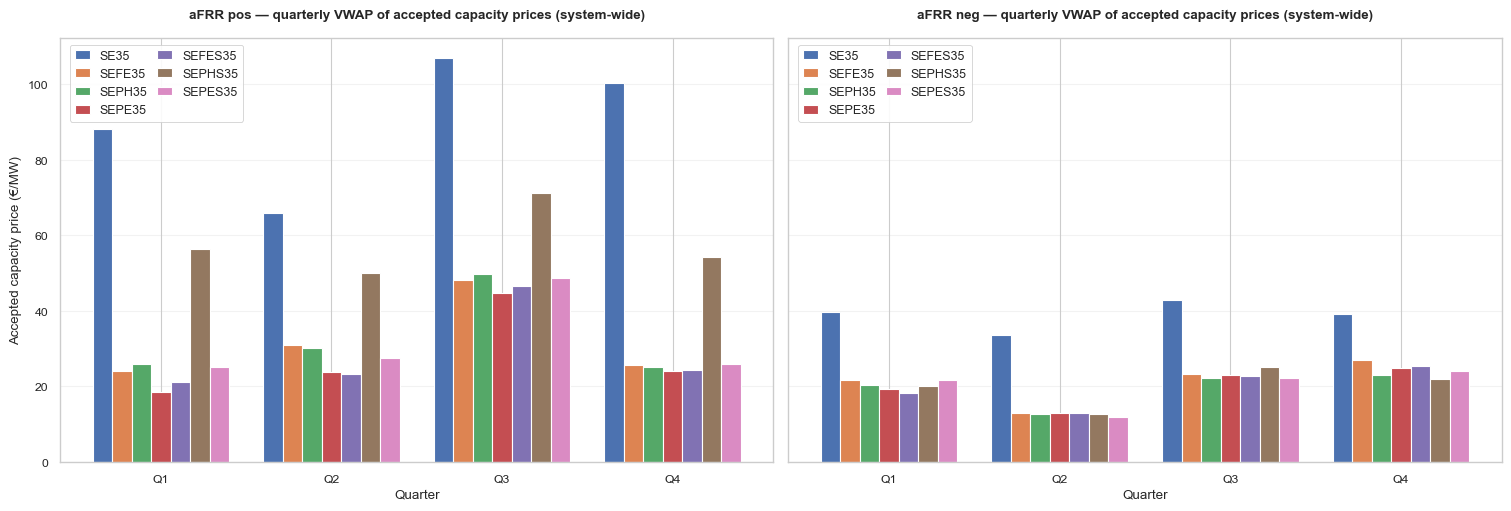

In [84]:
# --- Quarterly CRM comparison (SYSTEM-WIDE): CRM_pos + CRM_neg side-by-side ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_quarterly_crm_systemwide(
    system_quarter_agg: pd.DataFrame,
    scenarios: list,
    value_col: str = "vwap_accepted_price",  # best default for capacity prices
):
    # Filter for CRM markets
    sq = system_quarter_agg.copy()
    sq = sq[sq["market_id"].isin(["CRM_pos", "CRM_neg"])].copy()
    if sq.empty:
        print("[INFO] system_quarter_agg has no CRM_pos/CRM_neg rows.")
        return

    # Enforce scenario ordering
    sq["scenario_label"] = pd.Categorical(sq["scenario_label"], categories=scenarios, ordered=True)

    # Build pivots: quarter x scenario
    piv_pos = (
        sq[sq["market_id"] == "CRM_pos"]
        .pivot(index="quarter", columns="scenario_label", values=value_col)
        .reindex(index=[1, 2, 3, 4], columns=scenarios)
    )
    piv_neg = (
        sq[sq["market_id"] == "CRM_neg"]
        .pivot(index="quarter", columns="scenario_label", values=value_col)
        .reindex(index=[1, 2, 3, 4], columns=scenarios)
    )

    quarters = ["Q1", "Q2", "Q3", "Q4"]
    x = np.arange(4)
    n = len(scenarios)
    width = min(0.8 / max(n, 1), 0.18)  # cap bar width for readability

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

    def _plot(ax, pivot, title):
        if pivot.empty or pivot.dropna(how="all").empty:
            ax.set_title(title, fontweight="bold")
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            return

        # Ensure numeric
        pivot_num = pivot.apply(pd.to_numeric, errors="coerce")

        for i, scen in enumerate(scenarios):
            vals = pivot_num[scen].to_numpy(dtype=float)
            ax.bar(x + (i - (n - 1) / 2) * width, vals, width=width, label=scen)

        ax.set_xticks(x)
        ax.set_xticklabels(quarters)
        ax.grid(axis="y", alpha=0.25)
        ax.set_xlabel("Quarter")
        ax.set_title(title, fontweight="bold", pad=14)

        # ---- NEW: legend INSIDE each subplot (compact) ----
        leg = ax.legend(
            loc="upper left",
            bbox_to_anchor=(0.01, 0.99),   # inside, slight inset
            fontsize=9,
            ncol=2,                        # set 3 if you have many scenarios
            frameon=True,
            borderaxespad=0.2,
            handlelength=1.2,
            columnspacing=0.8,
        )
        leg.get_frame().set_alpha(0.9)
        leg.get_frame().set_linewidth(0.6)


    _plot(axes[0], piv_pos, f"aFRR pos — quarterly VWAP of accepted capacity prices (system-wide)")
    _plot(axes[1], piv_neg, f"aFRR neg — quarterly VWAP of accepted capacity prices (system-wide)")
    axes[0].set_ylabel("Accepted capacity price (€/MW)")

    # ---- DELETE this entire global legend block ----
    # handles, labels = axes[0].get_legend_handles_labels()
    # if handles:
    #     fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 6), frameon=False)

    plt.show()



# Use all scenarios in your preferred order:
plot_quarterly_crm_systemwide(
    system_quarter_agg=system_quarter_agg,
    scenarios=SCENARIO_ORDER,
    value_col="vwap_accepted_price",
)

# If you ever want mean instead (unweighted accepted mean), and if present:
# plot_quarterly_crm_systemwide(system_quarter_agg, SCENARIO_ORDER, value_col="accepted_price_mean")


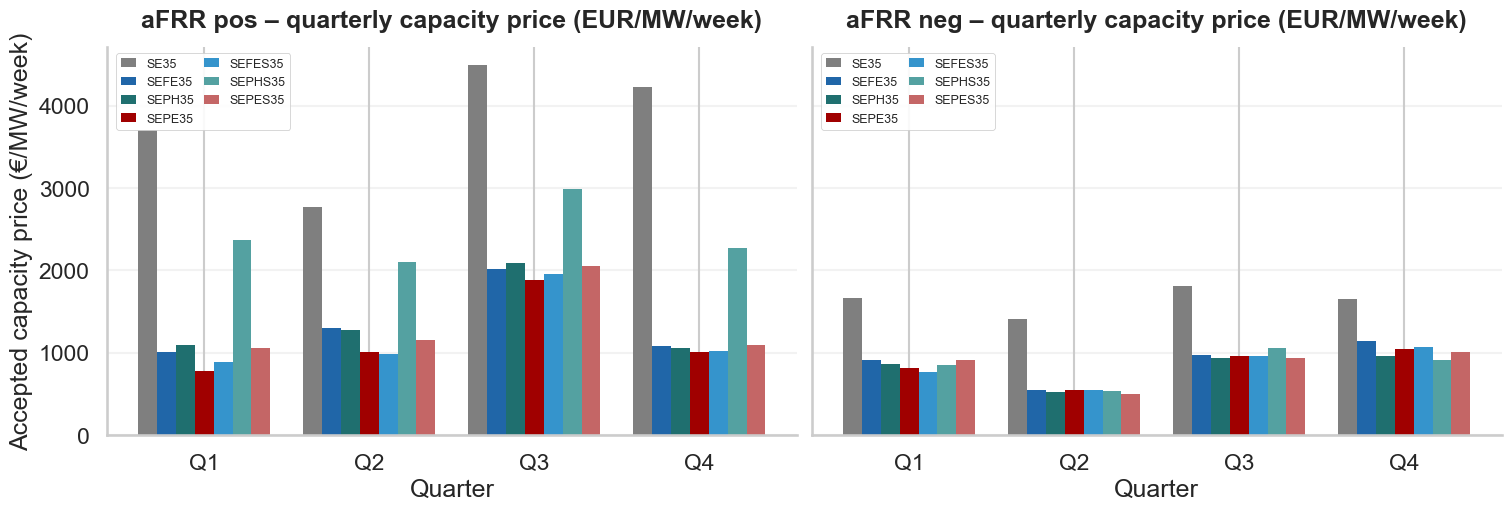

In [86]:
# --- Quarterly CRM comparison (SYSTEM-WIDE) in EUR/MW/week (seaborn-styled + fixed scenario colours) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Seaborn styling ----
sns.set_theme(style="whitegrid", context="talk")

# ---- Fixed scenario colour standard ----
COLOR_SE35_GRAY       = "#7f7f7f"

COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"

COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"

COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

SCENARIO_PALETTE = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}

def plot_quarterly_crm_systemwide_eur_per_mw_week(
    system_quarter_agg: pd.DataFrame,
    scenarios: list,
    blocks_per_day: int = 6,   # 4-hour products => 6 blocks/day
    days_per_week: int = 7,
    value_col: str = "vwap_accepted_price",
    scenario_palette: dict = SCENARIO_PALETTE,
):
    factor = blocks_per_day * days_per_week  # 42 for 4-hour blocks

    sq = system_quarter_agg.copy()
    sq = sq[sq["market_id"].isin(["CRM_pos", "CRM_neg"])].copy()
    if sq.empty:
        print("[INFO] system_quarter_agg has no CRM_pos/CRM_neg rows.")
        return

    # Convert to EUR/MW/week
    sq[value_col] = pd.to_numeric(sq[value_col], errors="coerce")
    sq["eur_per_mw_week"] = sq[value_col] * factor

    # Keep only scenarios we have colours for (prevents default colour cycle)
    scenarios_present = [s for s in scenarios if s in sq["scenario_label"].astype(str).unique()]
    scenarios_present = [s for s in scenarios_present if s in scenario_palette]

    if len(scenarios_present) == 0:
        print("[INFO] No matching scenarios found (after palette + presence filtering).")
        return

    # Enforce ordering
    sq["scenario_label"] = sq["scenario_label"].astype(str)
    sq = sq[sq["scenario_label"].isin(scenarios_present)].copy()
    sq["scenario_label"] = pd.Categorical(sq["scenario_label"], categories=scenarios_present, ordered=True)

    piv_pos = (
        sq[sq["market_id"] == "CRM_pos"]
        .pivot(index="quarter", columns="scenario_label", values="eur_per_mw_week")
        .reindex(index=[1, 2, 3, 4], columns=scenarios_present)
    )
    piv_neg = (
        sq[sq["market_id"] == "CRM_neg"]
        .pivot(index="quarter", columns="scenario_label", values="eur_per_mw_week")
        .reindex(index=[1, 2, 3, 4], columns=scenarios_present)
    )

    quarters = ["Q1", "Q2", "Q3", "Q4"]
    x = np.arange(4)
    n = len(scenarios_present)
    width = min(0.8 / max(n, 1), 0.18)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

    def _plot(ax, pivot, title):
        if pivot.empty or pivot.dropna(how="all").empty:
            ax.set_title(title, fontweight="bold")
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            return

        pivot_num = pivot.apply(pd.to_numeric, errors="coerce")

        for i, scen in enumerate(scenarios_present):
            vals = pivot_num[scen].to_numpy(dtype=float)
            ax.bar(
                x + (i - (n - 1) / 2) * width,
                vals,
                width=width,
                label=scen,
                color=scenario_palette.get(scen, "#7f7f7f"),
                linewidth=0
            )

        ax.set_xticks(x)
        ax.set_xticklabels(quarters)
        ax.grid(axis="y", alpha=0.25)
        ax.set_xlabel("Quarter")
        ax.set_title(title, fontweight="bold", pad=14)

        leg = ax.legend(
            loc="upper left",
            bbox_to_anchor=(0.01, 0.99),
            fontsize=9,
            ncol=2,
            frameon=True,
            borderaxespad=0.2,
            handlelength=1.2,
            columnspacing=0.8,
        )
        leg.get_frame().set_alpha(0.9)
        leg.get_frame().set_linewidth(0.6)

        sns.despine(ax=ax)

    _plot(axes[0], piv_pos, "aFRR pos – quarterly capacity price (EUR/MW/week)")
    _plot(axes[1], piv_neg, "aFRR neg – quarterly capacity price (EUR/MW/week)")
    axes[0].set_ylabel("Accepted capacity price (€/MW/week)")

    plt.show()


# Run with all scenarios (system-wide)
plot_quarterly_crm_systemwide_eur_per_mw_week(
    system_quarter_agg=system_quarter_agg,
    scenarios=SCENARIO_ORDER,
    blocks_per_day=6,
    days_per_week=7,
    value_col="vwap_accepted_price",
)


C:\Users\khm\AppData\Local\Temp\ipykernel_14396\410706824.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\khm\AppData\Local\Temp\ipykernel_14396\410706824.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


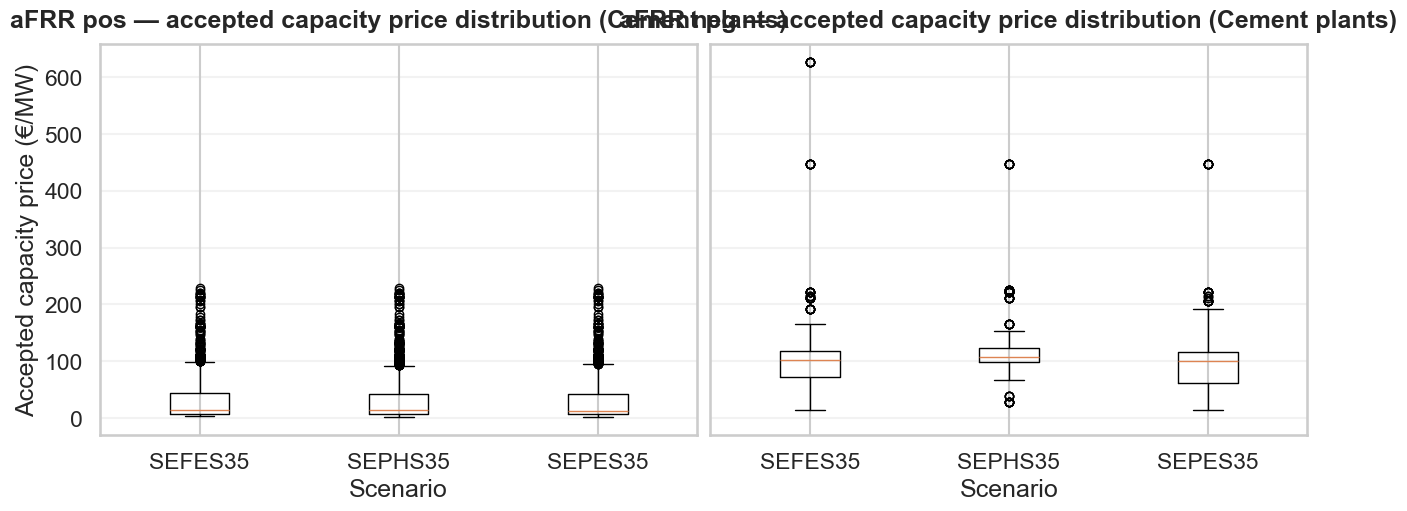

In [87]:
# --- Boxplots: accepted capacity price distribution (target units), CRM_pos vs CRM_neg side-by-side ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SELECTED_SCENARIOS = ["SEFES35", "SEPHS35", "SEPES35"]

def _prep_box_data(df: pd.DataFrame, market_id: str, scenarios: list) -> list:
    d = df[df["market_id"] == market_id].copy()
    if d.empty:
        return []

    d = d[d["scenario_label"].isin(scenarios)].copy()
    if d.empty:
        return []

    d["accepted_price"] = pd.to_numeric(d["accepted_price"], errors="coerce")
    d["accepted_volume"] = pd.to_numeric(d["accepted_volume"], errors="coerce")

    # accepted only
    d = d[d["accepted_price"].notna() & d["accepted_volume"].notna() & (d["accepted_volume"].abs() > 0)]
    if d.empty:
        return []

    # list of arrays in scenario order (for plt.boxplot)
    data = []
    for scen in scenarios:
        x = d.loc[d["scenario_label"] == scen, "accepted_price"].to_numpy(dtype=float)
        data.append(x)
    return data

def plot_crm_price_boxplots_target_units(crm_units: pd.DataFrame, scenarios: list):
    data_pos = _prep_box_data(crm_units, "CRM_pos", scenarios)
    data_neg = _prep_box_data(crm_units, "CRM_neg", scenarios)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)

    def _plot(ax, data, title):
        if not data or all(len(x) == 0 for x in data):
            ax.set_title(title, fontweight="bold")
            ax.axis("off")
            ax.text(0.5, 0.5, "No accepted data", ha="center", va="center")
            return

        ax.boxplot(
            data,
            labels=scenarios,
            showfliers=True,     # shows outliers like your example
            whis=1.5
        )
        ax.set_title(title, fontweight="bold", pad=12)
        ax.set_xlabel("Scenario")
        ax.grid(axis="y", alpha=0.25)

    _plot(axes[0], data_pos, "aFRR pos — accepted capacity price distribution (Cement plants)")
    _plot(axes[1], data_neg, "aFRR neg — accepted capacity price distribution (Cement plants)")

    axes[0].set_ylabel("Accepted capacity price (€/MW)")
    plt.show()

plot_crm_price_boxplots_target_units(crm_units, SELECTED_SCENARIOS)


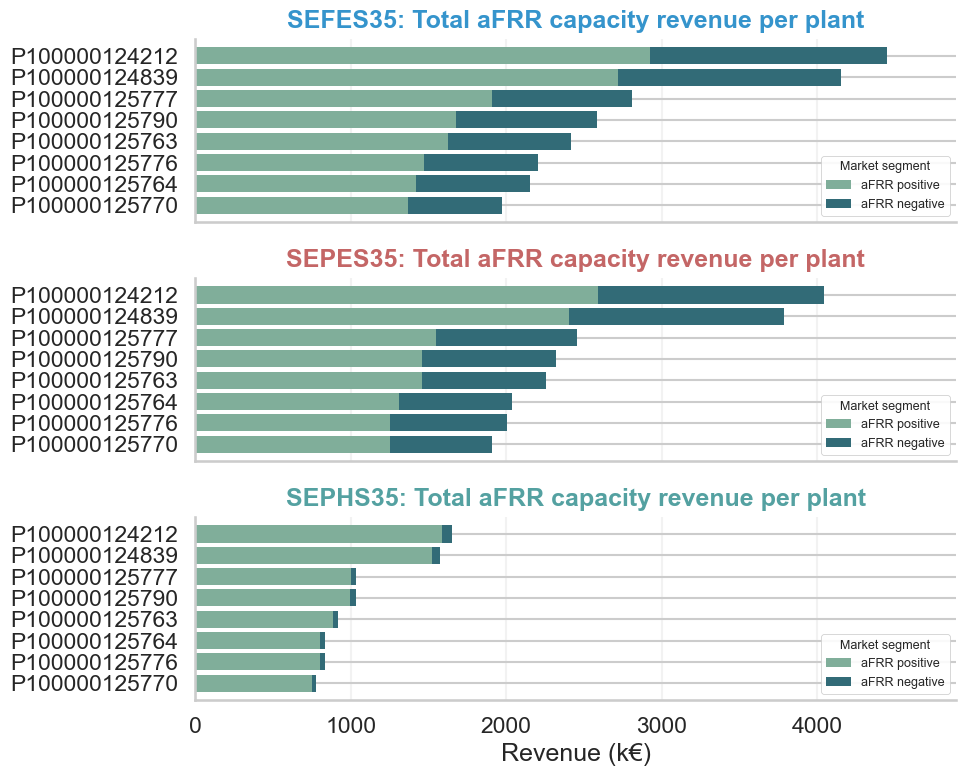

In [89]:
# --- Top-N unit revenues per scenario: horizontal STACKED bars (seaborn-styled + fixed scenario colours) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ---- Scenario colour standard (titles / accents) ----
COLOR_SE35_GRAY       = "#7f7f7f"
COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"
COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"
COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

SCENARIO_PALETTE = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}

# ---- Market colours (paper-friendly, from your reference image: Sequential teal) ----
# Teal1 #b5d1ae, Teal2 #80ae9a, Teal3 #568b87, Teal4 #326b77, Teal5 #1b485e, Teal6 #122740
MARKET_PALETTE = {
    "CRM_pos": "#80ae9a",  # Teal2 (lighter)
    "CRM_neg": "#326b77",  # Teal4 (darker)
}

# ---- settings ----
SELECTED_SCENARIOS = ["SEFES35", "SEPES35", "SEPHS35"]
TOP_N = 8  # show top N units per scenario (keeps plot compact)

# ---- choose input ----
# If you already have a revenue dataframe from your earlier cell, set it here:
# rev_df = YOUR_REVENUE_DF

# Fallback: build a proxy revenue df from crm_units (only if you don't already have rev_df)
if "rev_df" not in globals():
    tmp = crm_units.copy()
    tmp = tmp[tmp["market_id"].isin(["CRM_pos", "CRM_neg"]) & tmp["scenario_label"].isin(SELECTED_SCENARIOS)].copy()

    tmp["accepted_price"] = pd.to_numeric(tmp["accepted_price"], errors="coerce")
    tmp["accepted_volume"] = pd.to_numeric(tmp["accepted_volume"], errors="coerce")

    tmp = tmp[tmp["accepted_price"].notna() & tmp["accepted_volume"].notna() & (tmp["accepted_volume"].abs() > 0)]
    tmp["revenue_eur_proxy"] = tmp["accepted_price"] * tmp["accepted_volume"].abs()

    rev_df = (
        tmp.groupby(["scenario_label", "unit_id", "market_id"], as_index=False)["revenue_eur_proxy"]
        .sum()
        .rename(columns={"revenue_eur_proxy": "revenue_eur"})
    )
    rev_df["revenue_ke"] = rev_df["revenue_eur"] / 1e3  # k€ for plotting

# ---- ensure expected columns exist ----
required = {"scenario_label", "unit_id", "market_id"}
if not required.issubset(rev_df.columns):
    raise ValueError(f"rev_df must contain columns {required}. Found: {list(rev_df.columns)}")

# pick revenue column
if "revenue_ke" in rev_df.columns:
    rev_col = "revenue_ke"
elif "revenue_eur" in rev_df.columns:
    rev_df = rev_df.copy()
    rev_df["revenue_ke"] = pd.to_numeric(rev_df["revenue_eur"], errors="coerce") / 1e3
    rev_col = "revenue_ke"
else:
    raise ValueError("rev_df must contain revenue_ke or revenue_eur.")

# ---- filter ----
d = rev_df.copy()
d["scenario_label"] = d["scenario_label"].astype(str)
d["market_id"] = d["market_id"].astype(str)

d = d[d["scenario_label"].isin(SELECTED_SCENARIOS) & d["market_id"].isin(["CRM_pos", "CRM_neg"])].copy()
d[rev_col] = pd.to_numeric(d[rev_col], errors="coerce").fillna(0.0)

# ---- aggregate (scenario, unit, market) ----
agg = d.groupby(["scenario_label", "unit_id", "market_id"], as_index=False)[rev_col].sum()

# ---- select top N units per scenario by total revenue ----
tot = agg.groupby(["scenario_label", "unit_id"], as_index=False)[rev_col].sum()
top_units = (
    tot.sort_values(["scenario_label", rev_col], ascending=[True, False])
       .groupby("scenario_label")
       .head(TOP_N)
)

agg = agg.merge(top_units[["scenario_label", "unit_id"]], on=["scenario_label", "unit_id"], how="inner")

# ---- pivot for stacked bar plotting ----
piv = (
    agg.pivot_table(index=["scenario_label", "unit_id"], columns="market_id", values=rev_col, aggfunc="sum")
    .fillna(0.0)
)
if "CRM_pos" not in piv.columns: piv["CRM_pos"] = 0.0
if "CRM_neg" not in piv.columns: piv["CRM_neg"] = 0.0

piv["total"] = piv["CRM_pos"] + piv["CRM_neg"]
xmax = float(piv["total"].max()) * 1.10 if len(piv) else 1.0

# ---- plot: 3 rows (scenarios), horizontal stacked bars ----
fig, axes = plt.subplots(len(SELECTED_SCENARIOS), 1, figsize=(10, 2.7 * len(SELECTED_SCENARIOS)), sharex=True)
if len(SELECTED_SCENARIOS) == 1:
    axes = [axes]

for ax, scen in zip(axes, SELECTED_SCENARIOS):
    if scen not in piv.index.get_level_values(0):
        ax.axis("off")
        ax.text(0.5, 0.5, f"No data for {scen}", ha="center", va="center")
        continue

    sub = piv.loc[scen].sort_values("total", ascending=True)  # biggest at top
    y = np.arange(len(sub))

    pos_vals = sub["CRM_pos"].values
    neg_vals = sub["CRM_neg"].values

    ax.barh(y, pos_vals, label="aFRR positive", color=MARKET_PALETTE["CRM_pos"], linewidth=0)
    ax.barh(y, neg_vals, left=pos_vals, label="aFRR negative", color=MARKET_PALETTE["CRM_neg"], linewidth=0)

    ax.set_yticks(y)
    ax.set_yticklabels(sub.index.astype(str))
    ax.set_xlim(0, xmax)
    ax.grid(axis="x", alpha=0.25)

    # Title coloured by scenario (fixed standard)
    ax.set_title(f"{scen}: Total aFRR capacity revenue per plant", fontweight="bold", pad=8, color=SCENARIO_PALETTE.get(scen, "black"))

    # compact legend inside each subplot
    leg = ax.legend(title="Market segment", loc="lower right", fontsize=9, title_fontsize=9, frameon=True)
    leg.get_frame().set_alpha(0.9)
    leg.get_frame().set_linewidth(0.6)

    sns.despine(ax=ax)

axes[-1].set_xlabel("Revenue (k€)")
plt.tight_layout()
plt.show()


C:\Users\khm\AppData\Local\Temp\ipykernel_14396\487057830.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sq.groupby(["scenario_label", "market_id", "quarter"], as_index=False)["accepted_volume_abs_sum"]


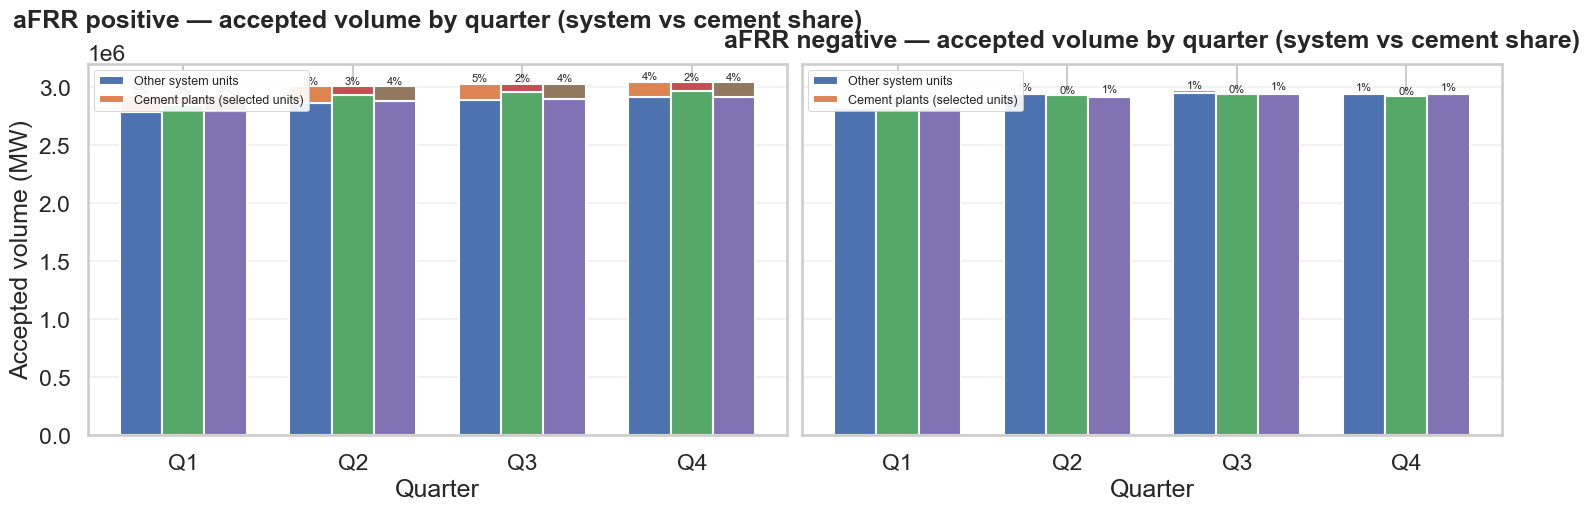

In [90]:
SCEN_LAST3 = ["SEFES35", "SEPHS35", "SEPES35"]
MARKETS = ["CRM_pos", "CRM_neg"]
QUARTERS = ["Q1", "Q2", "Q3", "Q4"]

# ---------- 1) System-wide totals from system_quarter_agg ----------
sq = system_quarter_agg.copy()
sq = sq[sq["scenario_label"].isin(SCEN_LAST3) & sq["market_id"].isin(MARKETS)].copy()

# total accepted volume (system-wide) per scenario/market/quarter
sys_vol = (
    sq.groupby(["scenario_label", "market_id", "quarter"], as_index=False)["accepted_volume_abs_sum"]
    .sum()
    .rename(columns={"accepted_volume_abs_sum": "sys_accepted_vol"})
)

# ---------- 2) Cement-plant accepted volumes from unit_extract (target units) ----------
# Use unit_extract if it contains all target units + CRM markets; otherwise use crm_units if that's your filtered target-unit df.
base_units = unit_extract.copy() if "unit_extract" in globals() else crm_units.copy()

u = base_units.copy()
u = u[u["scenario_label"].isin(SCEN_LAST3) & u["market_id"].isin(MARKETS)].copy()

u["accepted_volume"] = pd.to_numeric(u["accepted_volume"], errors="coerce")
u["end_time"] = pd.to_datetime(u["end_time"], errors="coerce")

# accepted only + quarter
u = u[u["accepted_volume"].notna() & (u["accepted_volume"].abs() > 0) & u["end_time"].notna()].copy()
u["quarter"] = u["end_time"].dt.quarter

cement_vol = (
    u.groupby(["scenario_label", "market_id", "quarter"], as_index=False)["accepted_volume"]
    .apply(lambda s: float(np.abs(s).sum()))
    .rename(columns={"accepted_volume": "cement_accepted_vol"})
)

# ---------- 3) Merge + compute remainder and share ----------
m = sys_vol.merge(cement_vol, on=["scenario_label", "market_id", "quarter"], how="left")
m["cement_accepted_vol"] = m["cement_accepted_vol"].fillna(0.0)

# Safety: cement should not exceed system (can happen if definitions differ). Clip for plotting.
m["cement_accepted_vol"] = np.minimum(m["cement_accepted_vol"], m["sys_accepted_vol"])
m["rest_accepted_vol"] = m["sys_accepted_vol"] - m["cement_accepted_vol"]
m["cement_share"] = np.where(m["sys_accepted_vol"] > 0, m["cement_accepted_vol"] / m["sys_accepted_vol"], np.nan)

# ---------- 4) Plot: grouped bars per quarter (scenario), stacked cement+rest ----------
quarters_idx = [1, 2, 3, 4]
x = np.arange(4)
n = len(SCEN_LAST3)
width = min(0.8 / n, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

def _panel(ax, market_id, title):
    sub = m[m["market_id"] == market_id].copy()
    if sub.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, f"No data for {market_id}", ha="center", va="center")
        return

    # pivot for plotting convenience
    piv_cement = sub.pivot(index="quarter", columns="scenario_label", values="cement_accepted_vol").reindex(index=quarters_idx, columns=SCEN_LAST3)
    piv_rest   = sub.pivot(index="quarter", columns="scenario_label", values="rest_accepted_vol").reindex(index=quarters_idx, columns=SCEN_LAST3)
    piv_share  = sub.pivot(index="quarter", columns="scenario_label", values="cement_share").reindex(index=quarters_idx, columns=SCEN_LAST3)

    for i, scen in enumerate(SCEN_LAST3):
        cement_vals = piv_cement[scen].to_numpy(dtype=float)
        rest_vals   = piv_rest[scen].to_numpy(dtype=float)
        xpos = x + (i - (n - 1) / 2) * width

        ax.bar(xpos, rest_vals, width=width, label="Other system units" if i == 0 else None)
        ax.bar(xpos, cement_vals, width=width, bottom=rest_vals, label="Cement plants (selected units)" if i == 0 else None)

        # optional: annotate share on top (compact)
        for j in range(4):
            sh = piv_share.loc[quarters_idx[j], scen]
            if pd.notna(sh) and (cement_vals[j] > 0):
                ax.text(xpos[j], rest_vals[j] + cement_vals[j], f"{sh*100:.0f}%", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(QUARTERS)
    ax.set_xlabel("Quarter")
    ax.set_title(title, fontweight="bold", pad=12)
    ax.grid(axis="y", alpha=0.25)

_panel(axes[0], "CRM_pos", "aFRR positive — accepted volume by quarter (system vs cement share)")
_panel(axes[1], "CRM_neg", "aFRR negative — accepted volume by quarter (system vs cement share)")
axes[0].set_ylabel("Accepted volume (MW)")

# legend inside each plot (compact)
for ax in axes:
    leg = ax.legend(loc="upper left", fontsize=9, frameon=True)
    leg.get_frame().set_alpha(0.9)
    leg.get_frame().set_linewidth(0.6)

plt.show()


C:\Users\khm\AppData\Local\Temp\ipykernel_14396\1406213621.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
C:\Users\khm\AppData\Local\Temp\ipykernel_14396\1406213621.py:141: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
C:\Users\khm\AppData\Local\Temp\ipyke

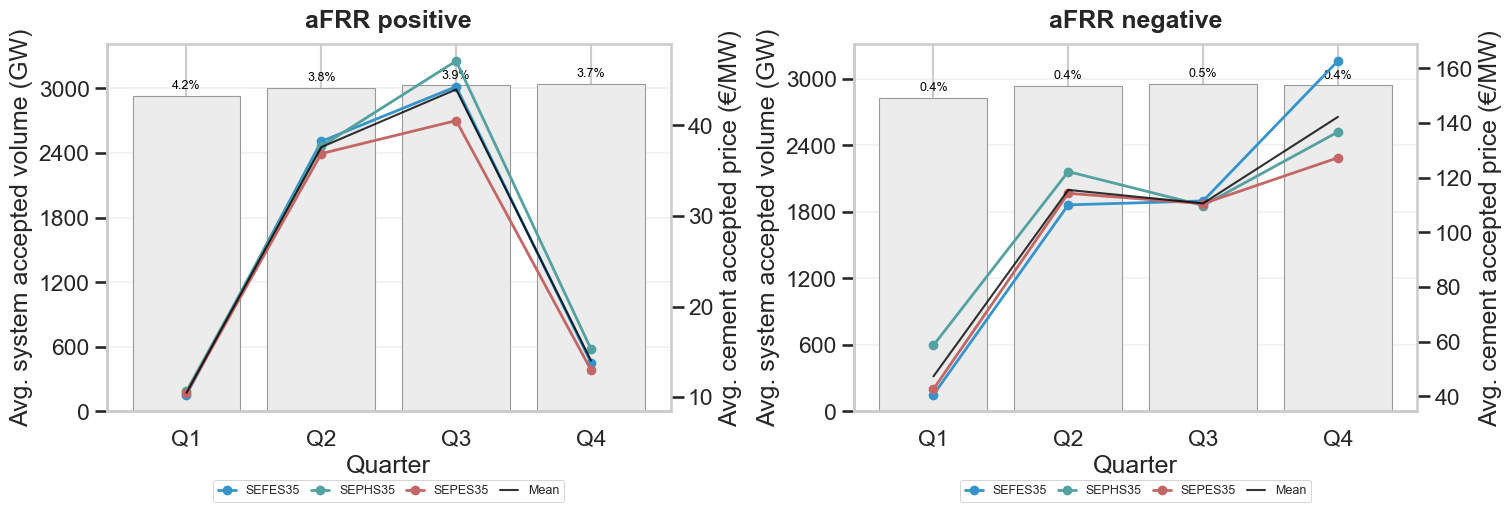

In [95]:
# --- System accepted volume + cement share labels + cement VWAP price (by quarter)
# Seaborn-styled + fixed scenario colours + legend moved so it doesn't cover % labels ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

sns.set_theme(style="whitegrid", context="talk")

# ---- Fixed scenario colour standard ----
COLOR_SE35_GRAY       = "#7f7f7f"
COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"
COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"
COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

SCENARIO_PALETTE = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}

SCEN_LAST3 = ["SEFES35", "SEPHS35", "SEPES35"]
QIDX = [1, 2, 3, 4]
QLAB = ["Q1", "Q2", "Q3", "Q4"]

PRICE_TO_WEEK = False
BLOCKS_PER_WEEK = 42
PRICE_FACTOR = BLOCKS_PER_WEEK if PRICE_TO_WEEK else 1.0
PRICE_UNIT = "€/MW/week" if PRICE_TO_WEEK else "€/MW"

def cement_vwap_price_by_quarter(crm_units: pd.DataFrame, market_id: str, scenarios: list) -> pd.Series:
    d = crm_units.copy()
    d = d[(d["market_id"] == market_id) & (d["scenario_label"].isin(scenarios))].copy()

    d["accepted_price"] = pd.to_numeric(d["accepted_price"], errors="coerce")
    d["accepted_volume"] = pd.to_numeric(d["accepted_volume"], errors="coerce")
    d["end_time"] = pd.to_datetime(d["end_time"], errors="coerce")

    d = d[d["accepted_price"].notna() & d["accepted_volume"].notna() & (d["accepted_volume"].abs() > 0) & d["end_time"].notna()].copy()
    if d.empty:
        return pd.Series(index=QIDX, dtype=float)

    d["quarter"] = d["end_time"].dt.quarter
    d["w"] = d["accepted_volume"].abs()

    vwap = (
        d.groupby(["scenario_label", "quarter"])
         .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
         .rename("vwap")
         .reset_index()
    )

    out = vwap.groupby("quarter")["vwap"].mean().reindex(QIDX)
    return out * PRICE_FACTOR

def system_volume_and_share_by_quarter(m: pd.DataFrame, market_id: str, scenarios: list):
    sub = m[(m["market_id"] == market_id) & (m["scenario_label"].isin(scenarios))].copy()
    if sub.empty:
        return pd.Series(index=QIDX, dtype=float), pd.Series(index=QIDX, dtype=float)

    sys_vol_mean = sub.groupby("quarter")["sys_accepted_vol"].mean().reindex(QIDX)
    share_pct_mean = (sub.groupby("quarter")["cement_share"].mean().reindex(QIDX) * 100.0)
    return sys_vol_mean, share_pct_mean

def fmt_gw(x, pos):
    return f"{x/1e3:.0f}"   # MW -> GW

# Plot styling
BAR_COLOR = "#ececec"
BAR_EDGE  = "#9a9a9a"
MARKERSZ  = 6

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

def _panel(ax, market_id, title):
    sys_vol, share_pct = system_volume_and_share_by_quarter(m, market_id, SCEN_LAST3)
    cement_price_mean = cement_vwap_price_by_quarter(crm_units, market_id, SCEN_LAST3)

    if sys_vol.isna().all():
        ax.axis("off")
        ax.text(0.5, 0.5, f"No data for {market_id}", ha="center", va="center")
        return

    x = np.arange(4)

    # Bars: system volume
    bars = ax.bar(x, sys_vol.to_numpy(dtype=float), color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(QLAB)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Avg. system accepted volume (GW)")
    ax.grid(axis="y", alpha=0.25)
    ax.set_title(title, fontweight="bold", pad=12)

    ax.yaxis.set_major_formatter(FuncFormatter(fmt_gw))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ymax = np.nanmax(sys_vol.to_numpy(dtype=float))
    ax.set_ylim(0, ymax * 1.12)

    # Cement share labels on bars
    for i, b in enumerate(bars):
        pct = share_pct.iloc[i]
        if pd.notna(pct):
            ax.text(
                b.get_x() + b.get_width()/2,
                b.get_height() + ymax * 0.012,
                f"{pct:.1f}%",
                ha="center", va="bottom",
                fontsize=9,
                color="black"
            )

    # Secondary axis: scenario-specific cement price lines + mean
    ax2 = ax.twinx()

    for scen in SCEN_LAST3:
        d = crm_units.copy()
        d = d[(d["market_id"] == market_id) & (d["scenario_label"].astype(str) == scen)].copy()
        d["accepted_price"] = pd.to_numeric(d["accepted_price"], errors="coerce")
        d["accepted_volume"] = pd.to_numeric(d["accepted_volume"], errors="coerce")
        d["end_time"] = pd.to_datetime(d["end_time"], errors="coerce")
        d = d[d["accepted_price"].notna() & d["accepted_volume"].notna() & (d["accepted_volume"].abs() > 0) & d["end_time"].notna()].copy()

        if d.empty:
            continue

        d["quarter"] = d["end_time"].dt.quarter
        d["w"] = d["accepted_volume"].abs()
        vwap_s = (
            d.groupby("quarter")
             .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
             .reindex(QIDX)
        ) * PRICE_FACTOR

        ax2.plot(
            x,
            vwap_s.to_numpy(dtype=float),
            marker="o",
            markersize=MARKERSZ,
            linewidth=2.0,
            color=SCENARIO_PALETTE.get(scen, "black"),
            label=scen
        )

    # Mean line (thin black)
    ax2.plot(
        x,
        cement_price_mean.to_numpy(dtype=float),
        linewidth=1.5,
        color="black",
        alpha=0.8,
        label="Mean"
    )

    ax2.set_ylabel(f"Avg. cement accepted price ({PRICE_UNIT})")
    ax2.grid(False)

    # ---- Legend moved OUTSIDE (below subplot) to avoid covering % labels ----
    handles, labels = ax2.get_legend_handles_labels()
    if handles:
        leg = ax2.legend(
            handles, labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),   # below axis
            ncol=min(len(labels), 4),
            fontsize=9,
            frameon=True,
            borderaxespad=0.2,
            handlelength=1.4,
            columnspacing=0.9,
        )
        leg.get_frame().set_alpha(0.95)
        leg.get_frame().set_linewidth(0.6)

    sns.despine(ax=ax)

_panel(axes[0], "CRM_pos", "aFRR positive")
_panel(axes[1], "CRM_neg", "aFRR negative")

# Reserve space for the below-legends
plt.subplots_adjust(bottom=0.22)

plt.show()


## 8) EOM (day-ahead): unit-level and system-level summaries

In [96]:
    # --- legend: place outside so it never covers % labels ---
    handles, labels = ax2.get_legend_handles_labels()
    if handles:
        leg = ax2.legend(
            handles, labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),   # below the subplot
            ncol=min(len(labels), 4),
            fontsize=9,
            frameon=True,
            borderaxespad=0.2,
            handlelength=1.4,
            columnspacing=0.9,
        )
        leg.get_frame().set_alpha(0.95)
        leg.get_frame().set_linewidth(0.6)


NameError: name 'ax2' is not defined

## 9) Combined CRM_pos + CRM_neg revenue per unit (target units)

In [97]:
# --- 9) Combined CRM revenue (target units) ---

if crm_units.empty:
    print("[INFO] No CRM rows for target units.")
else:
    comb = (crm_units
        .groupby(["unit_id", "market_id"], as_index=False)["revenue"].sum()
        .pivot(index="unit_id", columns="market_id", values="revenue")
        .fillna(0.0)
    )
    comb["Total_Combined"] = comb.get("CRM_pos", 0) + comb.get("CRM_neg", 0)
    comb = comb.sort_values("Total_Combined", ascending=False)

    display(comb.style.format("{:,.2f}"))


market_id,CRM_neg,CRM_pos,Total_Combined
unit_id,,,
P100000124212,"8,605,673.51","14,961,421.26","23,567,094.77"
P100000124839,"8,175,097.19","14,296,116.48","22,471,213.67"
P100000125777,"5,368,899.92","9,692,392.12","15,061,292.04"
P100000125790,"5,091,786.85","9,325,128.16","14,416,915.01"
P100000125763,"4,592,679.97","8,317,713.84","12,910,393.81"
P100000125776,"4,296,532.16","7,725,123.60","12,021,655.76"
P100000125764,"4,293,168.44","7,659,230.68","11,952,399.12"
P100000125770,"3,840,931.89","7,231,245.30","11,072,177.18"


C:\Users\khm\AppData\Local\Temp\ipykernel_14396\2998476862.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
C:\Users\khm\AppData\Local\Temp\ipykernel_14396\2998476862.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
C:\Users\khm\AppData\Local\Temp\ipyke

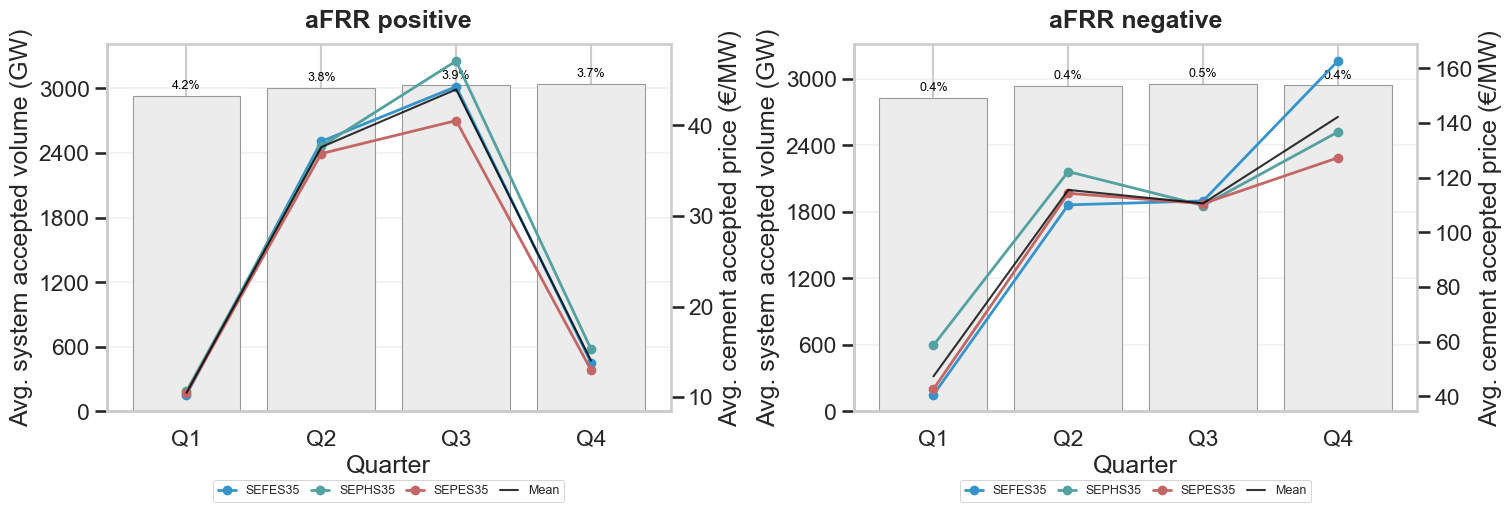

In [98]:
# --- System accepted volume + cement share labels + cement VWAP price (by quarter)
# Seaborn-styled + fixed scenario colours + legend moved so it doesn't cover % labels ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

sns.set_theme(style="whitegrid", context="talk")   # bigger than "paper"


# ---- Fixed scenario colour standard ----
COLOR_SE35_GRAY       = "#7f7f7f"
COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"
COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"
COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

SCENARIO_PALETTE = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}

SCEN_LAST3 = ["SEFES35", "SEPHS35", "SEPES35"]
QIDX = [1, 2, 3, 4]
QLAB = ["Q1", "Q2", "Q3", "Q4"]

PRICE_TO_WEEK = False
BLOCKS_PER_WEEK = 42
PRICE_FACTOR = BLOCKS_PER_WEEK if PRICE_TO_WEEK else 1.0
PRICE_UNIT = "€/MW/week" if PRICE_TO_WEEK else "€/MW"

def cement_vwap_price_by_quarter(crm_units: pd.DataFrame, market_id: str, scenarios: list) -> pd.Series:
    d = crm_units.copy()
    d = d[(d["market_id"] == market_id) & (d["scenario_label"].isin(scenarios))].copy()

    d["accepted_price"] = pd.to_numeric(d["accepted_price"], errors="coerce")
    d["accepted_volume"] = pd.to_numeric(d["accepted_volume"], errors="coerce")
    d["end_time"] = pd.to_datetime(d["end_time"], errors="coerce")

    d = d[d["accepted_price"].notna() & d["accepted_volume"].notna() & (d["accepted_volume"].abs() > 0) & d["end_time"].notna()].copy()
    if d.empty:
        return pd.Series(index=QIDX, dtype=float)

    d["quarter"] = d["end_time"].dt.quarter
    d["w"] = d["accepted_volume"].abs()

    vwap = (
        d.groupby(["scenario_label", "quarter"])
         .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
         .rename("vwap")
         .reset_index()
    )

    out = vwap.groupby("quarter")["vwap"].mean().reindex(QIDX)
    return out * PRICE_FACTOR

def system_volume_and_share_by_quarter(m: pd.DataFrame, market_id: str, scenarios: list):
    sub = m[(m["market_id"] == market_id) & (m["scenario_label"].isin(scenarios))].copy()
    if sub.empty:
        return pd.Series(index=QIDX, dtype=float), pd.Series(index=QIDX, dtype=float)

    sys_vol_mean = sub.groupby("quarter")["sys_accepted_vol"].mean().reindex(QIDX)
    share_pct_mean = (sub.groupby("quarter")["cement_share"].mean().reindex(QIDX) * 100.0)
    return sys_vol_mean, share_pct_mean

def fmt_gw(x, pos):
    return f"{x/1e3:.0f}"   # MW -> GW

# Plot styling
BAR_COLOR = "#ececec"
BAR_EDGE  = "#9a9a9a"
MARKERSZ  = 6

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

def _panel(ax, market_id, title):
    sys_vol, share_pct = system_volume_and_share_by_quarter(m, market_id, SCEN_LAST3)
    cement_price_mean = cement_vwap_price_by_quarter(crm_units, market_id, SCEN_LAST3)

    if sys_vol.isna().all():
        ax.axis("off")
        ax.text(0.5, 0.5, f"No data for {market_id}", ha="center", va="center")
        return

    x = np.arange(4)

    # Bars: system volume
    bars = ax.bar(x, sys_vol.to_numpy(dtype=float), color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(QLAB)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Avg. system accepted volume (GW)")
    ax.grid(axis="y", alpha=0.25)
    ax.set_title(title, fontweight="bold", pad=12)

    ax.yaxis.set_major_formatter(FuncFormatter(fmt_gw))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ymax = np.nanmax(sys_vol.to_numpy(dtype=float))
    ax.set_ylim(0, ymax * 1.12)

    # Cement share labels on bars
    for i, b in enumerate(bars):
        pct = share_pct.iloc[i]
        if pd.notna(pct):
            ax.text(
                b.get_x() + b.get_width()/2,
                b.get_height() + ymax * 0.012,
                f"{pct:.1f}%",
                ha="center", va="bottom",
                fontsize=9,
                color="black"
            )

    # Secondary axis: scenario-specific cement price lines + mean
    ax2 = ax.twinx()

    for scen in SCEN_LAST3:
        d = crm_units.copy()
        d = d[(d["market_id"] == market_id) & (d["scenario_label"].astype(str) == scen)].copy()
        d["accepted_price"] = pd.to_numeric(d["accepted_price"], errors="coerce")
        d["accepted_volume"] = pd.to_numeric(d["accepted_volume"], errors="coerce")
        d["end_time"] = pd.to_datetime(d["end_time"], errors="coerce")
        d = d[d["accepted_price"].notna() & d["accepted_volume"].notna() & (d["accepted_volume"].abs() > 0) & d["end_time"].notna()].copy()

        if d.empty:
            continue

        d["quarter"] = d["end_time"].dt.quarter
        d["w"] = d["accepted_volume"].abs()
        vwap_s = (
            d.groupby("quarter")
             .apply(lambda x: float(np.sum(x["accepted_price"] * x["w"]) / np.sum(x["w"])))
             .reindex(QIDX)
        ) * PRICE_FACTOR

        ax2.plot(
            x,
            vwap_s.to_numpy(dtype=float),
            marker="o",
            markersize=MARKERSZ,
            linewidth=2.0,
            color=SCENARIO_PALETTE.get(scen, "black"),
            label=scen
        )

    # Mean line (thin black)
    ax2.plot(
        x,
        cement_price_mean.to_numpy(dtype=float),
        linewidth=1.5,
        color="black",
        alpha=0.8,
        label="Mean"
    )

    ax2.set_ylabel(f"Avg. cement accepted price ({PRICE_UNIT})")
    ax2.grid(False)

    # ---- Legend moved OUTSIDE (below subplot) to avoid covering % labels ----
    handles, labels = ax2.get_legend_handles_labels()
    if handles:
        leg = ax2.legend(
            handles, labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),   # below axis
            ncol=min(len(labels), 4),
            fontsize=9,
            frameon=True,
            borderaxespad=0.2,
            handlelength=1.4,
            columnspacing=0.9,
        )
        leg.get_frame().set_alpha(0.95)
        leg.get_frame().set_linewidth(0.6)

    sns.despine(ax=ax)

_panel(axes[0], "CRM_pos", "aFRR positive")
_panel(axes[1], "CRM_neg", "aFRR negative")

# Reserve space for the below-legends
plt.subplots_adjust(bottom=0.22)

plt.show()


In [99]:
# ----- settings -----
EOM_MARKET = "EOM"
CHUNK_SIZE = 2_000_000  # tune if RAM issues
CACHE_DIR = Path("cache_market_analysis")
CACHE_DIR.mkdir(exist_ok=True, parents=True)
EOM_HOURLY_PARQUET = CACHE_DIR / "eom_hourly_prices.parquet"

# Sentinel filter (keep this strict; adjust only if you know more sentinels)
SENTINEL_PRICES = {-9999.0}

def build_eom_hourly_prices(
    scenarios: dict,
    chunk_size: int = CHUNK_SIZE,
    use_cache: bool = True
) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
    scenario_label, time, eom_price_vwap, eom_price_mean, eom_vol_sum, n_rows
    """
    if use_cache and EOM_HOURLY_PARQUET.exists():
        print("[CACHE] Loading", EOM_HOURLY_PARQUET)
        return pd.read_parquet(EOM_HOURLY_PARQUET)

    rows = []

    for scen, csv_path in scenarios.items():
        csv_path = str(csv_path)
        print("->", scen, csv_path)

        # Read minimal columns only
        usecols = ["end_time", "market_id", "accepted_price", "accepted_volume"]
        dtype = {"market_id": "string"}  # keep safe; parse numerics after read

        # Running accumulators by hour
        pw_sum = {}   # sum(price*vol)
        vol_sum = {}  # sum(vol)
        p_sum = {}    # sum(price)
        p_cnt = {}    # count(price)

        for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunk_size, dtype=dtype, low_memory=False):
            # Filter EOM only
            chunk = chunk[chunk["market_id"] == EOM_MARKET]
            if chunk.empty:
                continue

            # Parse time and numeric
            chunk["end_time"] = pd.to_datetime(chunk["end_time"], errors="coerce")
            chunk["accepted_price"] = pd.to_numeric(chunk["accepted_price"], errors="coerce")
            chunk["accepted_volume"] = pd.to_numeric(chunk["accepted_volume"], errors="coerce").abs()

            # Accepted rows only + sentinel filter
            m = (
                chunk["end_time"].notna()
                & chunk["accepted_price"].notna()
                & chunk["accepted_volume"].notna()
                & (chunk["accepted_volume"] > 0)
                & (~chunk["accepted_price"].isin(SENTINEL_PRICES))
            )
            chunk = chunk[m]
            if chunk.empty:
                continue

            # Hourly bucket
            chunk["time"] = chunk["end_time"].dt.floor("H")

            # Aggregate within chunk to reduce Python dict operations
            g = chunk.groupby("time", sort=False).agg(
                pw=("accepted_price", lambda s: 0.0),  # placeholder
            )
            # Faster explicit aggregates:
            grp = chunk.groupby("time", sort=False)
            pw = grp.apply(lambda x: float(np.sum(x["accepted_price"] * x["accepted_volume"])))
            vs = grp["accepted_volume"].sum()
            ps = grp["accepted_price"].sum()
            pc = grp["accepted_price"].count()

            for t, val in pw.items():
                pw_sum[t] = pw_sum.get(t, 0.0) + float(val)
            for t, val in vs.items():
                vol_sum[t] = vol_sum.get(t, 0.0) + float(val)
            for t, val in ps.items():
                p_sum[t] = p_sum.get(t, 0.0) + float(val)
            for t, val in pc.items():
                p_cnt[t] = p_cnt.get(t, 0) + int(val)

        # Build scenario rows
        times = sorted(vol_sum.keys())
        for t in times:
            v = vol_sum.get(t, 0.0)
            rows.append({
                "scenario_label": scen,
                "time": t,
                "eom_price_vwap": (pw_sum[t] / v) if v > 0 else np.nan,
                "eom_price_mean": (p_sum[t] / p_cnt[t]) if p_cnt[t] > 0 else np.nan,
                "eom_vol_sum": v,
                "n_rows": p_cnt.get(t, 0),
            })

    out = pd.DataFrame(rows).sort_values(["scenario_label", "time"])
    out.to_parquet(EOM_HOURLY_PARQUET, index=False)
    print("[DONE] Saved", EOM_HOURLY_PARQUET)
    return out

eom_hourly = build_eom_hourly_prices(SCENARIOS, chunk_size=CHUNK_SIZE, use_cache=True)
display(eom_hourly.head())


[CACHE] Loading cache_market_analysis\eom_hourly_prices.parquet


,scenario_label,time,eom_price_vwap,eom_price_mean,eom_vol_sum,n_rows
0,SE35,2035-01-02 01:00:00,0.000,0.000,213081.44658,2146
1,SE35,2035-01-02 02:00:00,1.204,1.204,233622.13965,2323
2,SE35,2035-01-02 03:00:00,0.000,0.000,135949.93347,1192
3,SE35,2035-01-02 04:00:00,0.000,0.000,137133.94914,1131
4,SE35,2035-01-02 05:00:00,0.000,0.000,147102.97621,1120


In [100]:
# Choose which price definition to compare
PRICE_SERIES_COL = "eom_price_vwap"  # or "eom_price_mean"

# Scenario pairs you described (flex has "S")
pairs = {
    "Full electrification": ("SEFE35", "SEFES35"),  # (inflex, flex)
    "P pathway":            ("SEPE35", "SEPES35"),
    "H pathway":            ("SEPH35", "SEPHS35"),
}

def build_delta_series(eom_hourly: pd.DataFrame, inflex: str, flex: str, col: str) -> pd.DataFrame:
    a = eom_hourly[eom_hourly["scenario_label"] == inflex][["time", col]].rename(columns={col: "price_inflex"})
    b = eom_hourly[eom_hourly["scenario_label"] == flex][["time", col]].rename(columns={col: "price_flex"})
    x = a.merge(b, on="time", how="inner").sort_values("time")
    x["delta"] = x["price_flex"] - x["price_inflex"]          # >0 flex higher price, <0 flex lower price
    x["abs_delta"] = x["delta"].abs()
    return x

def top_windows(x: pd.DataFrame, window_hours: int, top_k: int = 3):
    y = x.set_index("time").copy()
    y[f"roll_abs_{window_hours}h"] = y["abs_delta"].rolling(window_hours, min_periods=window_hours//2).mean()
    # pick top_k peaks, spaced apart by at least window size
    cand = y.dropna(subset=[f"roll_abs_{window_hours}h"]).sort_values(f"roll_abs_{window_hours}h", ascending=False)
    chosen = []
    used = set()
    for t, row in cand.iterrows():
        if any(abs((t - ct).total_seconds()) < window_hours*3600 for ct in chosen):
            continue
        chosen.append(t)
        if len(chosen) >= top_k:
            break
    windows = []
    for center in chosen:
        start = center - pd.Timedelta(hours=window_hours)
        end   = center + pd.Timedelta(hours=window_hours)
        windows.append((start, end, float(y.loc[center, f"roll_abs_{window_hours}h"])))
    return windows

delta_by_pathway = {}
events = {}

for name, (inflex, flex) in pairs.items():
    x = build_delta_series(eom_hourly, inflex, flex, PRICE_SERIES_COL)
    delta_by_pathway[name] = x

    # “interesting” day and week windows
    events[name] = {
        "top_days":  top_windows(x, window_hours=24,  top_k=2),
        "top_weeks": top_windows(x, window_hours=168, top_k=2),
    }

events


{'Full electrification': {'top_days': [(Timestamp('2035-01-26 08:00:00'),
    Timestamp('2035-01-28 08:00:00'),
    33.20754166666668),
   (Timestamp('2035-12-13 08:00:00'),
    Timestamp('2035-12-15 08:00:00'),
    30.603958333333335)],
  'top_weeks': [(Timestamp('2035-01-22 16:00:00'),
    Timestamp('2035-02-05 16:00:00'),
    11.363898809523814),
   (Timestamp('2035-12-01 04:00:00'),
    Timestamp('2035-12-15 04:00:00'),
    10.098945833333339)]},
 'P pathway': {'top_days': [(Timestamp('2035-01-25 17:00:00'),
    Timestamp('2035-01-27 17:00:00'),
    6.928125000000023),
   (Timestamp('2035-02-28 11:00:00'),
    Timestamp('2035-03-02 11:00:00'),
    4.888333333333336)],
  'top_weeks': [(Timestamp('2035-01-22 02:00:00'),
    Timestamp('2035-02-05 02:00:00'),
    1.3156250000000085),
   (Timestamp('2034-12-29 20:00:00'),
    Timestamp('2035-01-12 20:00:00'),
    1.287036956521739)]},
 'H pathway': {'top_days': [(Timestamp('2035-01-26 08:00:00'),
    Timestamp('2035-01-28 08:00:00'),
  

Selected window: 2035-01-22 16:00:00 -> 2035-02-05 16:00:00 | score: 11.363898809523814
s shape: (337, 5) | time min/max: 2035-01-22 16:00:00 2035-02-05 16:00:00


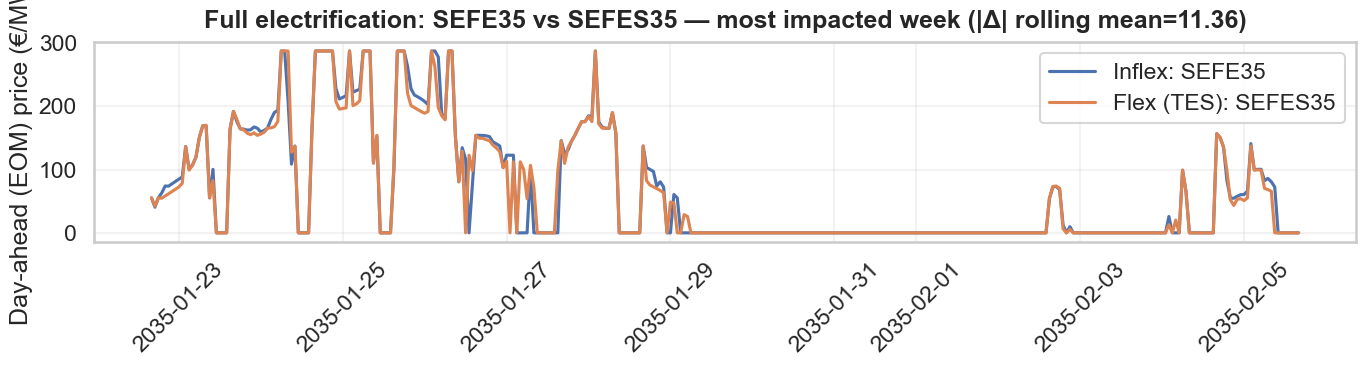

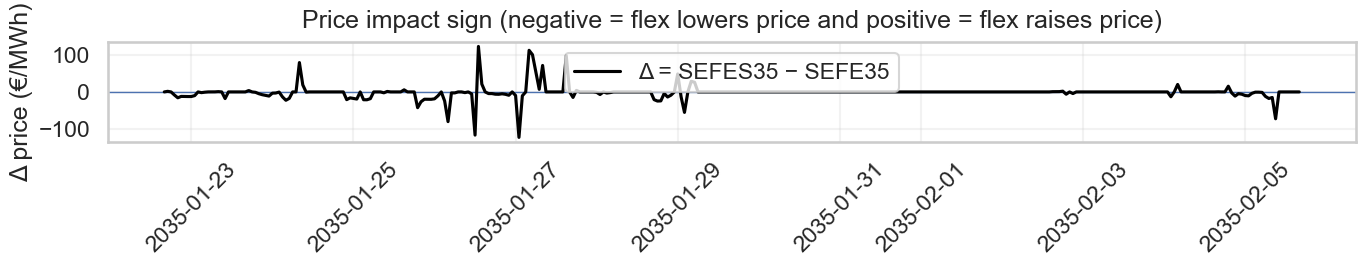

In [101]:
# --- choose which comparison you want ---
pathway_name = "Full electrification"
inflex_scen, flex_scen = "SEFE35", "SEFES35"

# --- pick the window (top week) ---
start, end, score = events[pathway_name]["top_weeks"][0]

# --- get the delta dataframe for that pathway ---
x = delta_by_pathway[pathway_name].copy()

# --- build the window slice 's' (THIS was missing) ---
s = x[(x["time"] >= start) & (x["time"] <= end)].copy()

print("Selected window:", start, "->", end, "| score:", score)
print("s shape:", s.shape, "| time min/max:", s["time"].min(), s["time"].max())

# --- plot 1: prices ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s["time"], s["price_inflex"], label=f"Inflex: {inflex_scen}")
ax.plot(s["time"], s["price_flex"],   label=f"Flex (TES): {flex_scen}")
ax.set_ylabel("Day-ahead (EOM) price (€/MWh)")
ax.grid(alpha=0.25)
ax.set_title(f"{pathway_name}: {inflex_scen} vs {flex_scen} — most impacted week (|Δ| rolling mean={score:.2f})",
             fontweight="bold", pad=10)
ax.legend(frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- plot 2: delta ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.axhline(0, linewidth=1)
ax.plot(s["time"], s["delta"], label=f"Δ = {flex_scen} − {inflex_scen}", color="black")
ax.set_ylabel("Δ price (€/MWh)")
ax.grid(alpha=0.25)
ax.set_title("Price impact sign (negative = flex lowers price and positive = flex raises price)", pad=10)
ax.legend(frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [48]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# === USER SETTINGS ===
BASE_DIR = Path(r"C:\Users\khm\ownCloud (3)\Dropbox\Ph.D\My publications\Journal paper\3\Simulation\Output")
TIME_ORIGIN = pd.Timestamp("2035-01-01 00:00:00")

# Use Parquet caching (recommended)
USE_PLANT_CACHE = True

# Where to store caches
CACHE_DIR = Path("cache_market_analysis")
CACHE_DIR.mkdir(exist_ok=True, parents=True)

PLANT_OPS_PARQUET   = CACHE_DIR / "plant_ops_all.parquet"          # big: plant×hour×scenario
FLEET_OPS_PARQUET   = CACHE_DIR / "plant_ops_fleet_hourly.parquet" # small: scenario×hour
MERGED_OPMKT_PARQUET = CACHE_DIR / "op_market_hourly.parquet"      # optional: scenario×hour

# Scenario mapping (your mapping)
SCENARIO_META = {
    2:  {"scenario_name": "SE35",    "config": "BAU", "tes": False},
    4:  {"scenario_name": "SEFE35",  "config": "FE",  "tes": False},
    5:  {"scenario_name": "SEPH35",  "config": "PH",  "tes": False},
    6:  {"scenario_name": "SEPE35",  "config": "PE",  "tes": False},
    10: {"scenario_name": "SEFES35", "config": "FE",  "tes": True},
    11: {"scenario_name": "SEPHS35", "config": "PH",  "tes": True},
    12: {"scenario_name": "SEPES35", "config": "PE",  "tes": True},
}

print("Cache dir:", CACHE_DIR.resolve())


Cache dir: C:\Manish_REPO\assume\examples\inputs\example_cement_plant_economics\cache_market_analysis


In [49]:
scenario_pattern = re.compile(r"^sim (\d+)_cement operation$")

scenario_dirs = []
for p in BASE_DIR.iterdir():
    if p.is_dir():
        m = scenario_pattern.match(p.name)
        if m:
            sim_id = int(m.group(1))
            scenario_dirs.append((sim_id, p))

scenario_dirs = sorted(scenario_dirs, key=lambda x: x[0])

if not scenario_dirs:
    raise FileNotFoundError(f"No folders like 'sim <id>_cement operation' found under:\n{BASE_DIR}")

unmapped = [sim_id for sim_id, _ in scenario_dirs if sim_id not in SCENARIO_META]
if unmapped:
    print("WARNING: found scenario folders without mapping in SCENARIO_META:", unmapped)

scenario_dirs_mapped = [(sim_id, p) for sim_id, p in scenario_dirs if sim_id in SCENARIO_META]
print("Mapped scenario sims discovered:", [sim_id for sim_id, _ in scenario_dirs_mapped])


Mapped scenario sims discovered: [2, 4, 5, 6, 10, 11, 12]


In [62]:
def parse_plant_id(filename: str) -> str:
    # e.g. "P100000124212_BAU.csv" -> "P100000124212"
    return filename.split("_")[0]

def load_one_plant_csv(csv_path: Path, sim_id: int) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    if "t" not in df.columns:
        raise KeyError(f"Missing 't' column in {csv_path}")

    meta = SCENARIO_META[sim_id]
    df["scenario_id"] = sim_id
    df["scenario_name"] = meta["scenario_name"]
    df["config"] = meta["config"]
    df["tes"] = meta["tes"]
    df["plant_id"] = parse_plant_id(csv_path.name)

    # timestamp
    if np.issubdtype(df["t"].dtype, np.number):
        df["timestamp"] = TIME_ORIGIN + pd.to_timedelta(df["t"].astype(int), unit="h")
    else:
        ts = pd.to_datetime(df["t"], errors="coerce")
        df["timestamp"] = ts if ts.notna().all() else df["t"]

    return df


In [51]:
if USE_PLANT_CACHE and PLANT_OPS_PARQUET.exists():
    print("[CACHE] Loading plant ops:", PLANT_OPS_PARQUET)
    df_ops_all = pd.read_parquet(PLANT_OPS_PARQUET)
else:
    print("[SCAN] Reading plant *_BAU.csv files from scenario folders...")

    rows = []
    missing = []

    for sim_id, scen_dir in scenario_dirs_mapped:
        csv_paths = sorted(scen_dir.glob("*_BAU.csv"))
        if not csv_paths:
            missing.append(sim_id)
            continue

        for csv_path in csv_paths:
            rows.append(load_one_plant_csv(csv_path, sim_id))

    if missing:
        print("WARNING: no *_BAU.csv found for sims:", missing)

    if not rows:
        raise FileNotFoundError("No plant CSVs were loaded. Check file patterns '*_BAU.csv' and folder names.")

    df_ops_all = pd.concat(rows, ignore_index=True)

    # Put metadata columns first
    meta_cols = ["scenario_id", "scenario_name", "config", "tes", "plant_id", "t", "timestamp"]
    other_cols = [c for c in df_ops_all.columns if c not in meta_cols]
    df_ops_all = df_ops_all[meta_cols + other_cols]

    # Save cache
    df_ops_all.to_parquet(PLANT_OPS_PARQUET, index=False)
    print("[DONE] Saved plant ops cache:", PLANT_OPS_PARQUET)

print("df_ops_all shape:", df_ops_all.shape)
display(df_ops_all.head(3))


[CACHE] Loading plant ops: cache_market_analysis\plant_ops_all.parquet
df_ops_all shape: (490560, 42)


,scenario_id,scenario_name,config,tes,plant_id,t,timestamp,Preheater Power [MW_e],Calciner Power [MW_e],Kiln Power [MW_e],Electrolyser Power [MW_e],Cement Mill Power [MW_e],TES Heater Power [MW_e],Calciner NG [MW_th],Calciner H2 [MW_th],Calciner Coal [MW_th],Kiln NG [MW_th],Kiln H2 [MW_th],Kiln Coal [MW_th],Calciner Heat Out [MW_th],Kiln Heat Out [MW_th],Calciner Effective Heat In [MW_th],Waste Heat to Preheater [MW_th],TES Charge [MW_th],TES Discharge [MW_th],TES SOC [MWh_th],Preheater CO2 [tCO2/step],Calciner CO2 process [tCO2/step],Calciner CO2 energy [tCO2/step],Calciner CO2 total [tCO2/step],Kiln CO2 [tCO2/step],Total CO2 [tCO2/step],Elec Price [€/MWh_e],NG Price [€/MWh_th],Coal Price [€/MWh_th],H2 Price [€/MWh_th],CO2 Price [€/tCO2],Total Variable Cost [€],Total Power Input [MW_e],Clinker Rate [t/h],Variable Cost [€/h],Marginal Cost [€/t clinker]
0,2,SE35,BAU,False,P100000124212,0,2035-01-01 00:00:00,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,160.674391,0.0,0.0,97.689332,144.606952,87.920399,144.606952,NaN,NaN,NaN,NaN,NaN,140.21224,54.789967,195.002207,33.312062,228.31427,41.500,30.95,8.27,70.0,160.0,38667.131346,0.0,261.59,38667.131346,147.815786
1,2,SE35,BAU,False,P100000124212,1,2035-01-01 01:00:00,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,160.674391,0.0,0.0,97.689332,144.606952,87.920399,144.606952,NaN,NaN,NaN,NaN,NaN,140.21224,54.789967,195.002207,33.312062,228.31427,42.704,30.95,8.27,70.0,160.0,38667.136575,0.0,261.59,38667.136575,147.815806
2,2,SE35,BAU,False,P100000124212,2,2035-01-01 02:00:00,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,160.674391,0.0,0.0,97.689332,144.606952,87.920399,144.606952,NaN,NaN,NaN,NaN,NaN,140.21224,54.789967,195.002207,33.312062,228.31427,41.500,30.95,8.27,70.0,160.0,38667.131346,0.0,261.59,38667.131346,147.815786


In [52]:
# Only aggregate columns that actually exist
AGG_MAP = {
    "Total Power Input [MW_e]": ("cement_power_MW", "sum"),
    "TES Charge [MW_th]": ("tes_charge_MWth", "sum"),
    "TES Discharge [MW_th]": ("tes_discharge_MWth", "sum"),
    "TES SOC [MWh_th]": ("tes_soc_MWhth", "sum"),
    "Electrolyser Power [MW_e]": ("electrolyser_power_MW", "sum"),
    "Clinker Rate [t/h]": ("clinker_rate_tph", "sum"),
}

available_cols = [c for c in AGG_MAP if c in df_ops_all.columns]
if not available_cols:
    raise KeyError("None of the expected operational columns were found in df_ops_all.")

agg_dict = {c: AGG_MAP[c][1] for c in available_cols}

if USE_PLANT_CACHE and FLEET_OPS_PARQUET.exists():
    print("[CACHE] Loading fleet ops:", FLEET_OPS_PARQUET)
    fleet_ops_hourly = pd.read_parquet(FLEET_OPS_PARQUET)
else:
    fleet_ops_hourly = (
        df_ops_all
        .groupby(["scenario_name", "timestamp"], as_index=False)
        .agg(agg_dict)
        .rename(columns={c: AGG_MAP[c][0] for c in available_cols})
    )

    fleet_ops_hourly.to_parquet(FLEET_OPS_PARQUET, index=False)
    print("[DONE] Saved fleet ops cache:", FLEET_OPS_PARQUET)

print("fleet_ops_hourly shape:", fleet_ops_hourly.shape)
display(fleet_ops_hourly.head())


[CACHE] Loading fleet ops: cache_market_analysis\plant_ops_fleet_hourly.parquet
fleet_ops_hourly shape: (61320, 8)


,scenario_name,timestamp,cement_power_MW,tes_charge_MWth,tes_discharge_MWth,tes_soc_MWhth,electrolyser_power_MW,clinker_rate_tph
0,SE35,2035-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
1,SE35,2035-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
2,SE35,2035-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
3,SE35,2035-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
4,SE35,2035-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,1353.76


In [53]:
# OPTIONAL: only if you have the exact plant ids for your targeted units
# Example:
# TARGET_PLANTS = ["P100000124212", "P100000124213"]
TARGET_PLANTS = None  # set list if needed

if TARGET_PLANTS is not None:
    df_ops_sel = df_ops_all[df_ops_all["plant_id"].isin(TARGET_PLANTS)].copy()
    fleet_ops_hourly_sel = (
        df_ops_sel
        .groupby(["scenario_name", "timestamp"], as_index=False)
        .agg(agg_dict)
        .rename(columns={c: AGG_MAP[c][0] for c in available_cols})
    )
    display(fleet_ops_hourly_sel.head())
    print("Selected-fleet shape:", fleet_ops_hourly_sel.shape)


In [54]:
if "eom_hourly" not in globals():
    print("NOTE: eom_hourly not found. Run your market EOM hourly extraction first.")
else:
    eom_h = eom_hourly.rename(columns={"scenario_label": "scenario_name", "time": "timestamp"}).copy()

    op_market_hourly = fleet_ops_hourly.merge(
        eom_h,
        on=["scenario_name", "timestamp"],
        how="inner"
    )

    # Cache merged dataset too (optional but very useful)
    op_market_hourly.to_parquet(MERGED_OPMKT_PARQUET, index=False)
    print("[DONE] Saved merged op-market cache:", MERGED_OPMKT_PARQUET)

    print("op_market_hourly shape:", op_market_hourly.shape)
    display(op_market_hourly.head())


[DONE] Saved merged op-market cache: cache_market_analysis\op_market_hourly.parquet
op_market_hourly shape: (60984, 12)


,scenario_name,timestamp,cement_power_MW,tes_charge_MWth,tes_discharge_MWth,tes_soc_MWhth,electrolyser_power_MW,clinker_rate_tph,eom_price_vwap,eom_price_mean,eom_vol_sum,n_rows
0,SE35,2035-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,213081.44658,2146
1,SE35,2035-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,1.204,1.204,233622.13965,2323
2,SE35,2035-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,135949.93347,1192
3,SE35,2035-01-02 04:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,137133.94914,1131
4,SE35,2035-01-02 05:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,147102.97621,1120


In [55]:
TARGET_PLANTS = [
    "P100000124212", "P100000124839", "P100000125777", "P100000125790",
    "P100000125763", "P100000125764", "P100000125776", "P100000125770"
]

print("Target plants:", len(TARGET_PLANTS))


Target plants: 8


In [56]:
TARGET_FLEET_PARQUET = CACHE_DIR / "plant_ops_target_fleet_hourly.parquet"

# Ensure the plant_id exists
if "plant_id" not in df_ops_all.columns:
    raise KeyError("df_ops_all missing 'plant_id' column")

df_ops_target = df_ops_all[df_ops_all["plant_id"].isin(TARGET_PLANTS)].copy()

if df_ops_target.empty:
    raise ValueError("df_ops_target is empty. Check TARGET_PLANTS IDs vs df_ops_all['plant_id'].")

# Build same agg dict as in Cell 5
AGG_MAP = {
    "Total Power Input [MW_e]": ("cement_power_MW", "sum"),
    "TES Charge [MW_th]": ("tes_charge_MWth", "sum"),
    "TES Discharge [MW_th]": ("tes_discharge_MWth", "sum"),
    "TES SOC [MWh_th]": ("tes_soc_MWhth", "sum"),
    "Electrolyser Power [MW_e]": ("electrolyser_power_MW", "sum"),
    "Clinker Rate [t/h]": ("clinker_rate_tph", "sum"),
}

available_cols = [c for c in AGG_MAP if c in df_ops_target.columns]
if not available_cols:
    raise KeyError("None of the expected operational columns found for target plants.")

agg_dict = {c: AGG_MAP[c][1] for c in available_cols}

if USE_PLANT_CACHE and TARGET_FLEET_PARQUET.exists():
    print("[CACHE] Loading targeted fleet ops:", TARGET_FLEET_PARQUET)
    fleet_ops_target_hourly = pd.read_parquet(TARGET_FLEET_PARQUET)
else:
    fleet_ops_target_hourly = (
        df_ops_target
        .groupby(["scenario_name", "timestamp"], as_index=False)
        .agg(agg_dict)
        .rename(columns={c: AGG_MAP[c][0] for c in available_cols})
    )
    fleet_ops_target_hourly.to_parquet(TARGET_FLEET_PARQUET, index=False)
    print("[DONE] Saved targeted fleet ops cache:", TARGET_FLEET_PARQUET)

print("fleet_ops_target_hourly shape:", fleet_ops_target_hourly.shape)
display(fleet_ops_target_hourly.head())


[CACHE] Loading targeted fleet ops: cache_market_analysis\plant_ops_target_fleet_hourly.parquet
fleet_ops_target_hourly shape: (61320, 8)


,scenario_name,timestamp,cement_power_MW,tes_charge_MWth,tes_discharge_MWth,tes_soc_MWhth,electrolyser_power_MW,clinker_rate_tph
0,SE35,2035-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
1,SE35,2035-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
2,SE35,2035-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
3,SE35,2035-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,1353.76
4,SE35,2035-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,1353.76


In [57]:
if "eom_hourly" not in globals():
    print("NOTE: eom_hourly not found. Run market EOM hourly extraction first.")
else:
    eom_h = eom_hourly.rename(columns={"scenario_label": "scenario_name", "time": "timestamp"}).copy()

    op_market_target_hourly = fleet_ops_target_hourly.merge(
        eom_h,
        on=["scenario_name", "timestamp"],
        how="inner"
    )

    OP_MKT_TARGET_PARQUET = CACHE_DIR / "op_market_target_hourly.parquet"
    op_market_target_hourly.to_parquet(OP_MKT_TARGET_PARQUET, index=False)
    print("[DONE] Saved targeted op-market cache:", OP_MKT_TARGET_PARQUET)

    print("op_market_target_hourly shape:", op_market_target_hourly.shape)
    display(op_market_target_hourly.head())


[DONE] Saved targeted op-market cache: cache_market_analysis\op_market_target_hourly.parquet
op_market_target_hourly shape: (60984, 12)


,scenario_name,timestamp,cement_power_MW,tes_charge_MWth,tes_discharge_MWth,tes_soc_MWhth,electrolyser_power_MW,clinker_rate_tph,eom_price_vwap,eom_price_mean,eom_vol_sum,n_rows
0,SE35,2035-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,213081.44658,2146
1,SE35,2035-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,1.204,1.204,233622.13965,2323
2,SE35,2035-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,135949.93347,1192
3,SE35,2035-01-02 04:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,137133.94914,1131
4,SE35,2035-01-02 05:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,147102.97621,1120


In [58]:
from pathlib import Path
import pandas as pd

CACHE_DIR = Path("cache_market_analysis")
OP_MKT_TARGET_PARQUET = CACHE_DIR / "op_market_target_hourly.parquet"

if OP_MKT_TARGET_PARQUET.exists():
    print("[CACHE] Loading:", OP_MKT_TARGET_PARQUET)
    op_market_target_hourly = pd.read_parquet(OP_MKT_TARGET_PARQUET)
else:
    # Fallback: build it if you already have fleet_ops_target_hourly + eom_hourly in memory
    if "fleet_ops_target_hourly" not in globals():
        raise NameError("fleet_ops_target_hourly not found. Run targeted fleet aggregation first.")
    if "eom_hourly" not in globals():
        raise NameError("eom_hourly not found. Run EOM hourly price extraction first.")

    eom_h = eom_hourly.rename(columns={"scenario_label": "scenario_name", "time": "timestamp"}).copy()
    op_market_target_hourly = fleet_ops_target_hourly.merge(
        eom_h, on=["scenario_name", "timestamp"], how="inner"
    )
    op_market_target_hourly.to_parquet(OP_MKT_TARGET_PARQUET, index=False)
    print("[DONE] Saved:", OP_MKT_TARGET_PARQUET)

# Basic sanity
op_market_target_hourly["timestamp"] = pd.to_datetime(op_market_target_hourly["timestamp"], errors="coerce")
print("op_market_target_hourly shape:", op_market_target_hourly.shape)
display(op_market_target_hourly.head(3))


[CACHE] Loading: cache_market_analysis\op_market_target_hourly.parquet
op_market_target_hourly shape: (60984, 12)


,scenario_name,timestamp,cement_power_MW,tes_charge_MWth,tes_discharge_MWth,tes_soc_MWhth,electrolyser_power_MW,clinker_rate_tph,eom_price_vwap,eom_price_mean,eom_vol_sum,n_rows
0,SE35,2035-01-02 01:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,213081.44658,2146
1,SE35,2035-01-02 02:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,1.204,1.204,233622.13965,2323
2,SE35,2035-01-02 03:00:00,0.0,0.0,0.0,0.0,0.0,1353.76,0.000,0.000,135949.93347,1192


In [59]:
import numpy as np
import pandas as pd

PRICE_COL = "eom_price_vwap"  # change to "eom_price_mean" if you prefer

pairs = {
    "Full electrification (TES effect)": ("SEFE35", "SEFES35"),  # inflex, flex
    "Partial electrification PE (TES effect)": ("SEPE35", "SEPES35"),
    "Partial electrification PH (TES effect)": ("SEPH35", "SEPHS35"),
}

def build_pair_frame(df, inflex, flex, price_col):
    a = df[df["scenario_name"] == inflex][["timestamp", price_col]].rename(columns={price_col: "price_inflex"})
    b = df[df["scenario_name"] == flex][["timestamp", price_col]].rename(columns={price_col: "price_flex"})
    x = a.merge(b, on="timestamp", how="inner").sort_values("timestamp")
    x["delta_price"] = x["price_flex"] - x["price_inflex"]
    x["abs_delta_price"] = x["delta_price"].abs()
    return x

delta_series = {name: build_pair_frame(op_market_target_hourly, inflex, flex, PRICE_COL)
                for name, (inflex, flex) in pairs.items()}

for k, v in delta_series.items():
    print(k, "rows:", len(v), "| time:", v["timestamp"].min(), "->", v["timestamp"].max())


Full electrification (TES effect) rows: 8712 | time: 2035-01-02 01:00:00 -> 2035-12-31 00:00:00
Partial electrification PE (TES effect) rows: 8712 | time: 2035-01-02 01:00:00 -> 2035-12-31 00:00:00
Partial electrification PH (TES effect) rows: 8712 | time: 2035-01-02 01:00:00 -> 2035-12-31 00:00:00


In [60]:
import pandas as pd
import numpy as np

def pick_top_windows(x: pd.DataFrame, window_hours=168, top_k=2, min_separation_hours=None):
    """
    Picks top_k windows by max rolling mean(|Δprice|).
    Returns list of dicts: start, end, center, score
    """
    min_separation_hours = min_separation_hours or window_hours
    y = x.set_index("timestamp").copy()
    y["score"] = y["abs_delta_price"].rolling(window_hours, min_periods=window_hours//2).mean()

    cand = y.dropna(subset=["score"]).sort_values("score", ascending=False)
    chosen_centers = []
    out = []

    for center, row in cand.iterrows():
        if any(abs((center - c).total_seconds()) < min_separation_hours * 3600 for c in chosen_centers):
            continue
        chosen_centers.append(center)
        out.append({
            "center": center,
            "start": center - pd.Timedelta(hours=window_hours),
            "end": center + pd.Timedelta(hours=window_hours),
            "score": float(row["score"]),
        })
        if len(out) >= top_k:
            break

    return out

events = {name: pick_top_windows(x, window_hours=168, top_k=2) for name, x in delta_series.items()}

for name, ws in events.items():
    print("\n", name)
    for i, w in enumerate(ws, 1):
        print(f"  {i}) {w['start']} -> {w['end']} | score={w['score']:.3f}")



 Full electrification (TES effect)
  1) 2035-01-22 16:00:00 -> 2035-02-05 16:00:00 | score=11.364
  2) 2035-12-01 04:00:00 -> 2035-12-15 04:00:00 | score=10.099

 Partial electrification PE (TES effect)
  1) 2035-01-22 02:00:00 -> 2035-02-05 02:00:00 | score=1.316
  2) 2034-12-29 20:00:00 -> 2035-01-12 20:00:00 | score=1.287

 Partial electrification PH (TES effect)
  1) 2035-01-22 13:00:00 -> 2035-02-05 13:00:00 | score=11.395
  2) 2035-12-01 03:00:00 -> 2035-12-15 03:00:00 | score=11.217


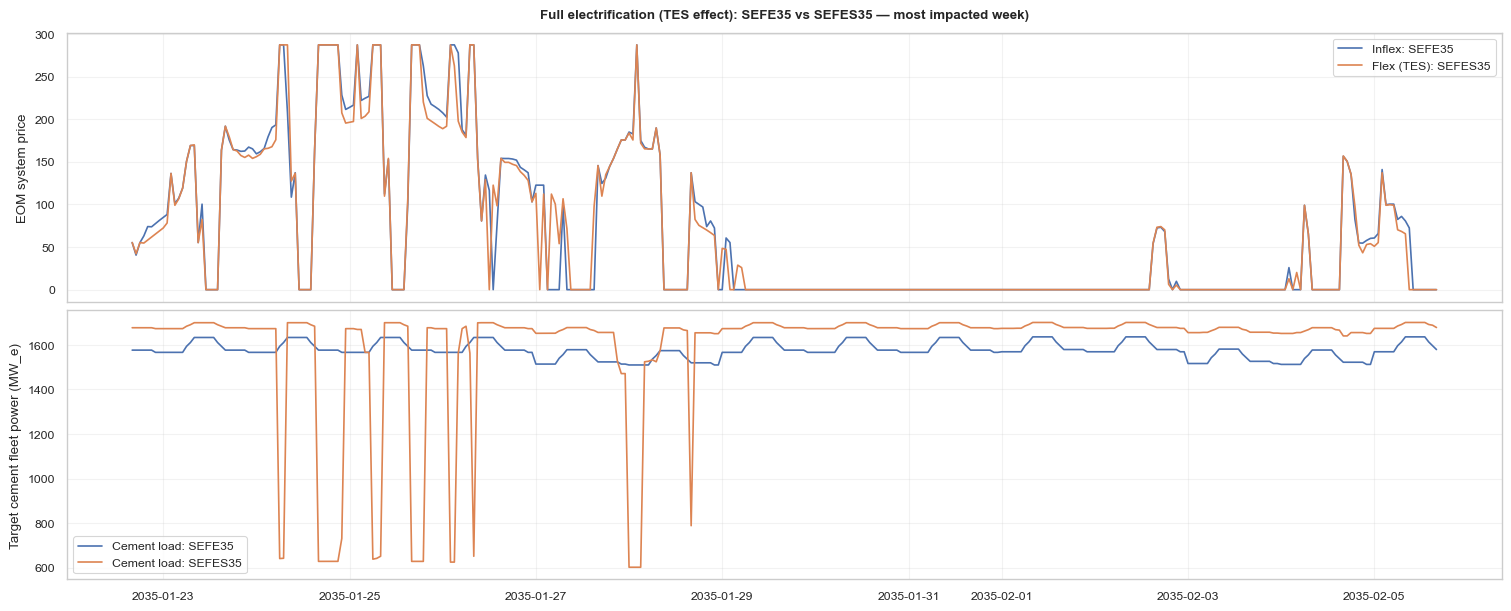

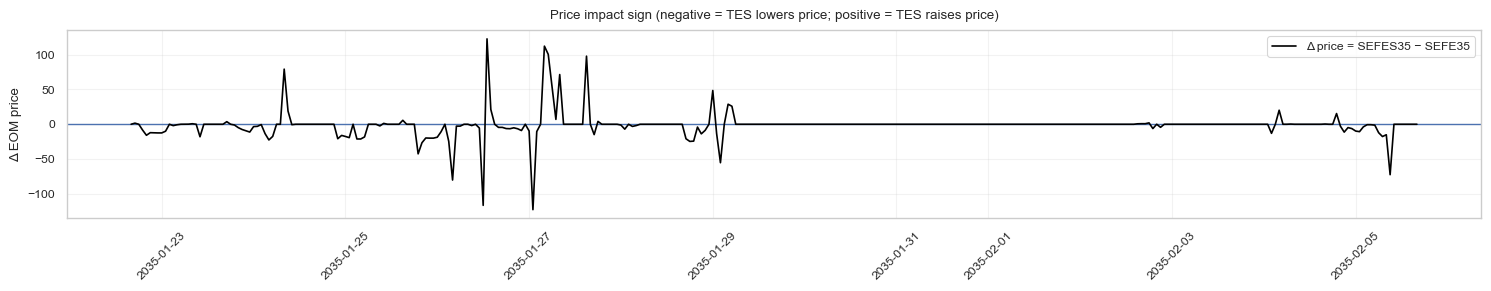

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_mechanism_week(df_opmkt, pathway_name, inflex, flex, window, price_col=PRICE_COL):
    start, end, score = window["start"], window["end"], window["score"]

    d = df_opmkt[(df_opmkt["timestamp"] >= start) & (df_opmkt["timestamp"] <= end)].copy()
    d = d[d["scenario_name"].isin([inflex, flex])].copy()
    if d.empty:
        print("[INFO] No data in window for", pathway_name)
        return

    # Ensure sort
    d = d.sort_values(["scenario_name", "timestamp"])

    # Pivot for easy plotting
    piv = d.pivot_table(index="timestamp", columns="scenario_name", values=price_col, aggfunc="mean")
    power = d.pivot_table(index="timestamp", columns="scenario_name", values="cement_power_MW", aggfunc="mean")

    # TES columns might not exist for BAU/inflex; handle safely
    tes_charge = d.pivot_table(index="timestamp", columns="scenario_name", values="tes_charge_MWth", aggfunc="mean") if "tes_charge_MWth" in d.columns else None
    tes_dis = d.pivot_table(index="timestamp", columns="scenario_name", values="tes_discharge_MWth", aggfunc="mean") if "tes_discharge_MWth" in d.columns else None
    tes_soc = d.pivot_table(index="timestamp", columns="scenario_name", values="tes_soc_MWhth", aggfunc="mean") if "tes_soc_MWhth" in d.columns else None

    # Delta series
    aligned = piv[[inflex, flex]].dropna()
    delta = aligned[flex] - aligned[inflex]

    fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True, constrained_layout=True)

    # (1) System price
    axes[0].plot(piv.index, piv[inflex], label=f"Inflex: {inflex}")
    axes[0].plot(piv.index, piv[flex],   label=f"Flex (TES): {flex}")
    axes[0].set_ylabel("EOM system price")
    axes[0].set_title(f"{pathway_name}: {inflex} vs {flex} — most impacted week)",
                      fontweight="bold", pad=10)
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=True)

    # (2) Targeted cement fleet load
    axes[1].plot(power.index, power[inflex], label=f"Cement load: {inflex}")
    axes[1].plot(power.index, power[flex],   label=f"Cement load: {flex}")
    axes[1].set_ylabel("Target cement fleet power (MW_e)")
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=True)

    # # (3) TES operation (flex only usually)
    # if tes_charge is not None and tes_dis is not None:
    #     if flex in tes_charge.columns:
    #         axes[2].plot(tes_charge.index, tes_charge.get(flex), label="TES charge (MW_th)")
    #     if flex in tes_dis.columns:
    #         axes[2].plot(tes_dis.index, tes_dis.get(flex), label="TES discharge (MW_th)")
    #     if tes_soc is not None and flex in tes_soc.columns:
    #         ax2 = axes[2].twinx()
    #         ax2.plot(tes_soc.index, tes_soc.get(flex), label="TES SOC (MWh_th)")
    #         ax2.set_ylabel("TES SOC (MWh_th)")
    #         # merge legends
    #         h1, l1 = axes[2].get_legend_handles_labels()
    #         h2, l2 = ax2.get_legend_handles_labels()
    #         if h1 or h2:
    #             axes[2].legend(h1 + h2, l1 + l2, frameon=True, loc="upper left")
    #     else:
    #         axes[2].legend(frameon=True)

    #     axes[2].set_ylabel("TES power (MW_th)")
    #     axes[2].grid(alpha=0.25)
    # else:
    #     axes[2].axis("off")
    #     axes[2].text(0.5, 0.5, "TES signals not available in dataset", ha="center", va="center")

    plt.show()

    # Optional: delta plot as a separate compact figure (often useful in appendix)
    fig, ax = plt.subplots(figsize=(15, 3))
    ax.axhline(0, linewidth=1)
    ax.plot(delta.index, delta.values, color="black", label=f"Δ price = {flex} − {inflex}")
    ax.set_ylabel("Δ EOM price")
    ax.set_title("Price impact sign (negative = TES lowers price; positive = TES raises price)", pad=8)
    ax.grid(alpha=0.25)
    ax.legend(frameon=True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example: plot Full electrification (first/top window)
pathway = "Full electrification (TES effect)"
inflex, flex = pairs[pathway]
plot_mechanism_week(op_market_target_hourly, pathway, inflex, flex, events[pathway][0], price_col=PRICE_COL)



===  Full electrification (TES effect) ===


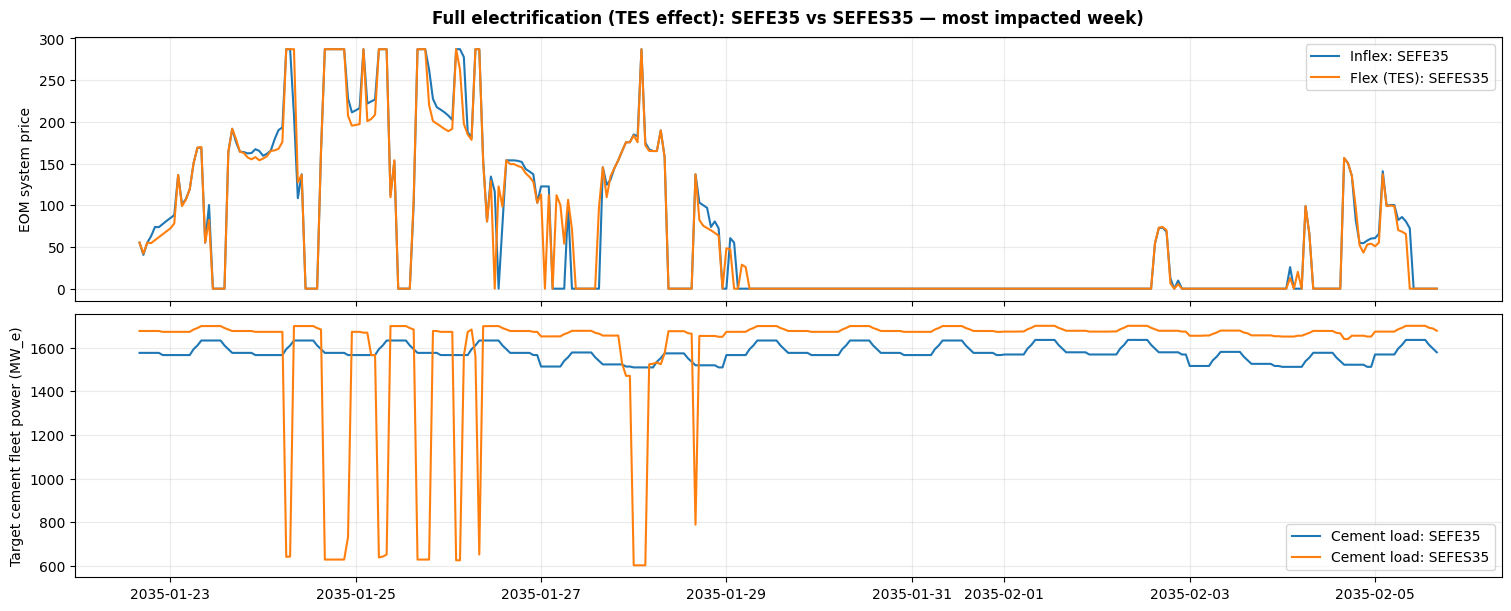

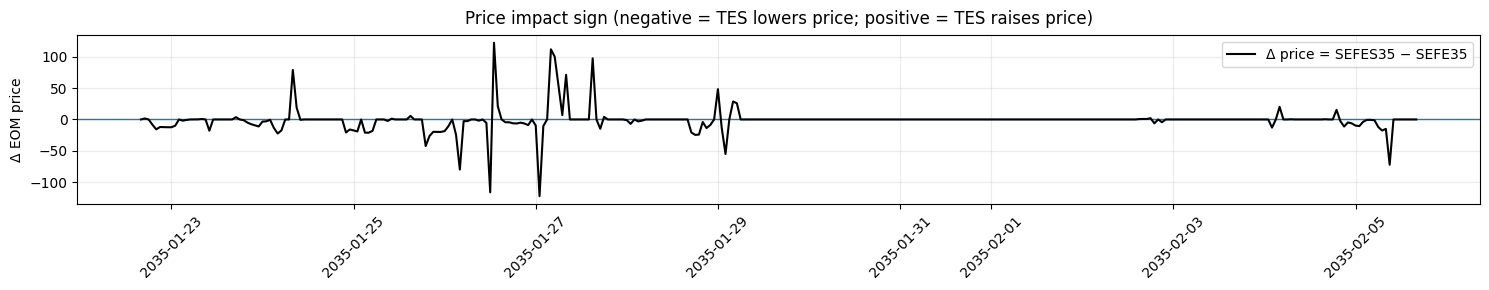


===  Partial electrification PE (TES effect) ===


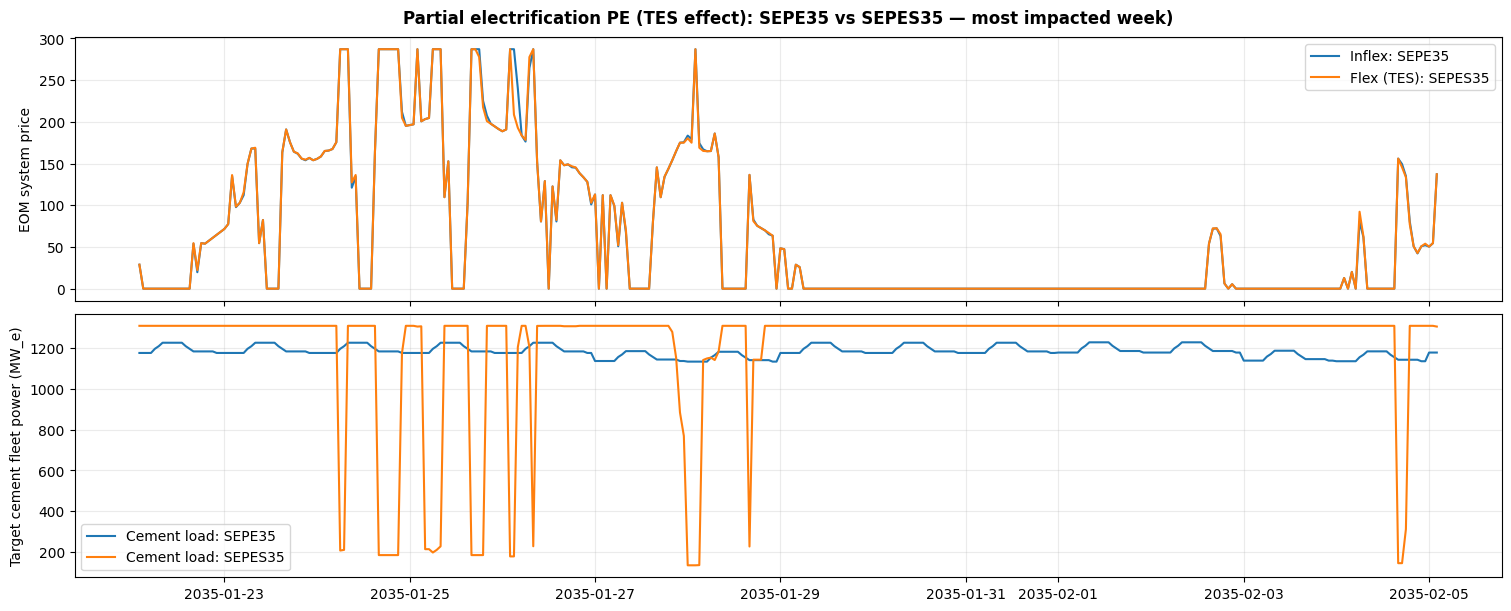

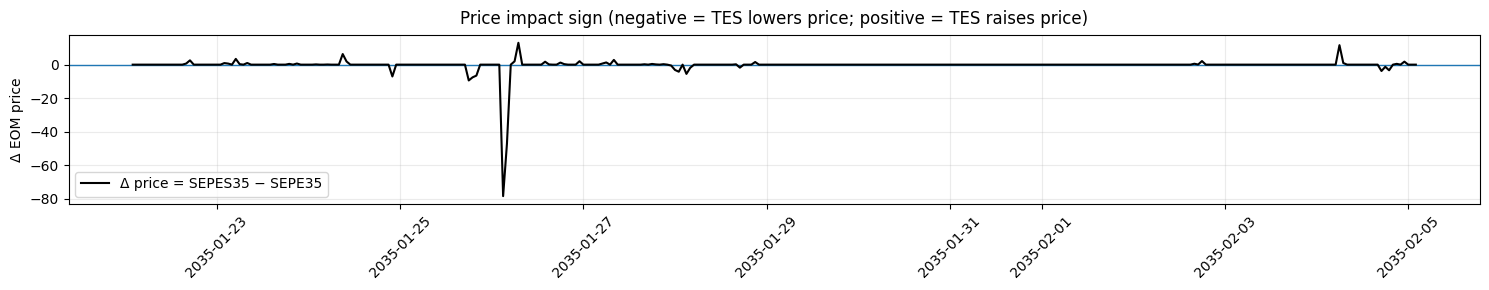


===  Partial electrification PH (TES effect) ===


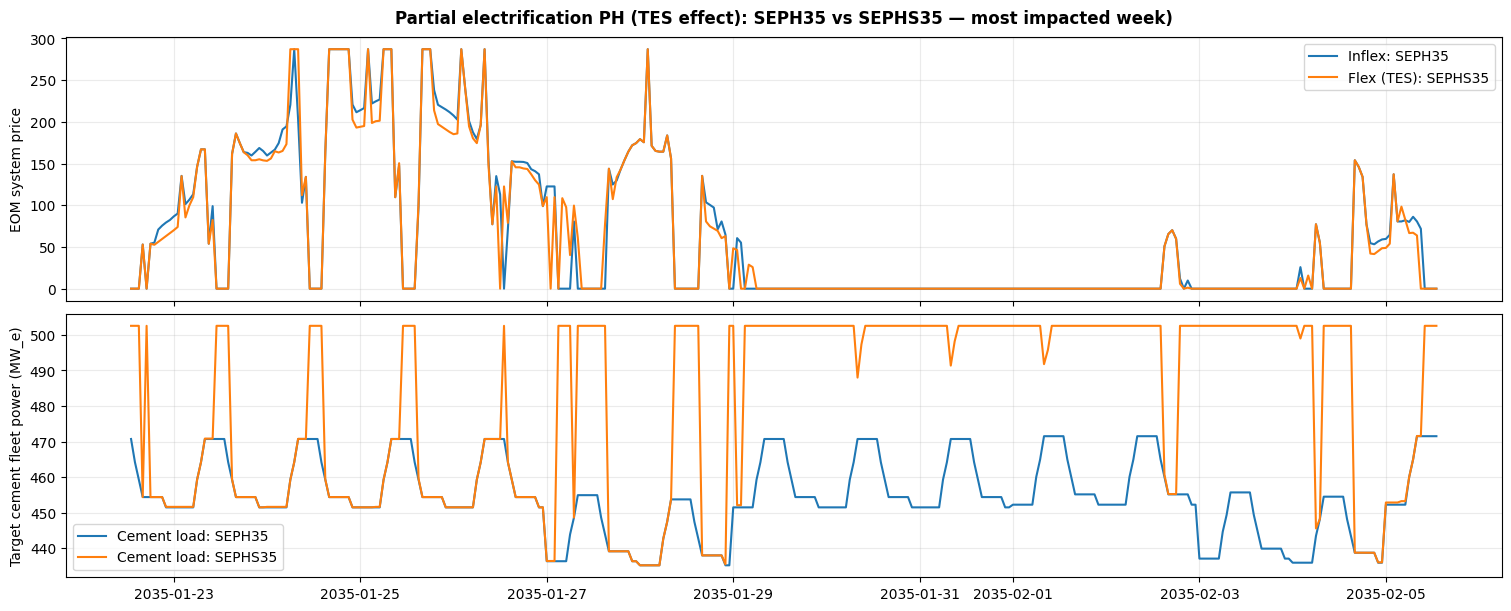

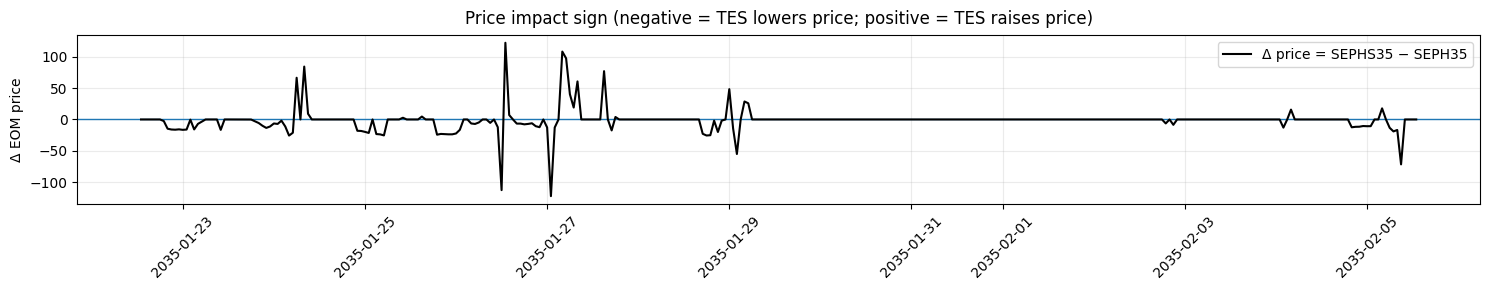

In [43]:
for pathway, (inflex, flex) in pairs.items():
    print("\n=== ", pathway, "===")
    plot_mechanism_week(op_market_target_hourly, pathway, inflex, flex, events[pathway][0], price_col=PRICE_COL)


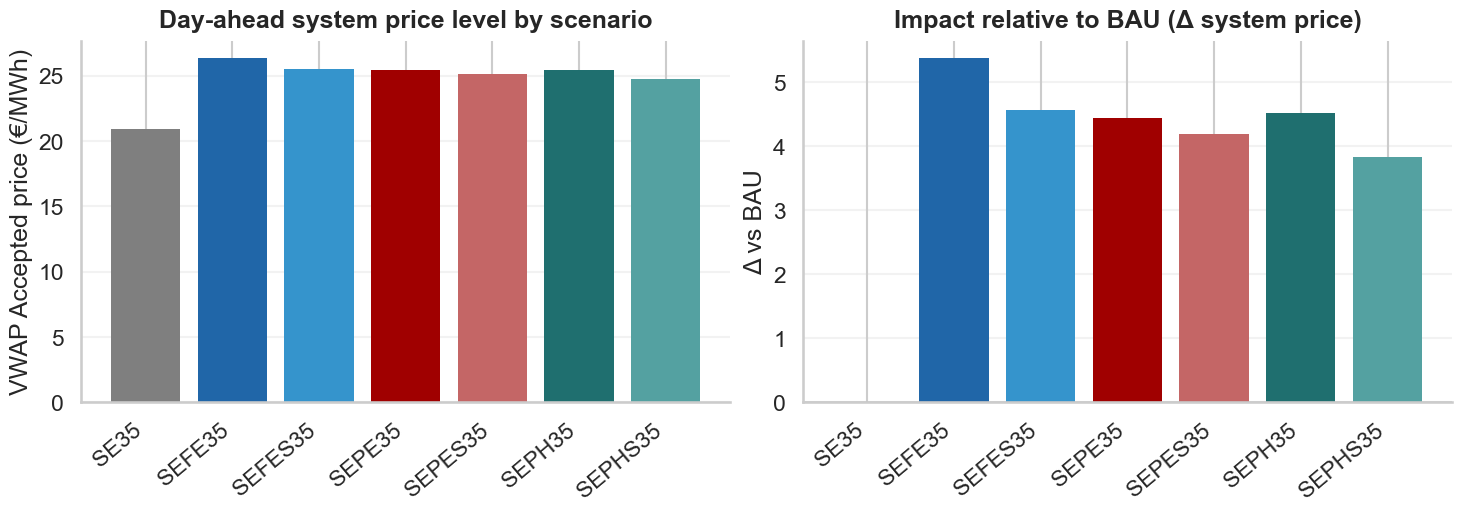

In [67]:
# --- EOM (day-ahead) system price level by scenario + Δ vs BAU (SE35) ---
# Seaborn-styled + FIXED scenario colours + x-axis uses actual scenario names

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")   # bigger than "paper"

# ---- Fixed scenario colour standard ----
COLOR_SE35_GRAY       = "#7f7f7f"
COLOR_SEFE35_DARK     = "#2066a8"
COLOR_SEFES35_LIGHT   = "#3594cc"
COLOR_SEPH35_DARK     = "#1f6f6f"
COLOR_SEPHS35_LIGHT   = "#54a1a1"
COLOR_SEPE35_DARK     = "#a00000"
COLOR_SEPES35_LIGHT   = "#c46666"

SCENARIO_PALETTE = {
    "SE35":    COLOR_SE35_GRAY,
    "SEFE35":  COLOR_SEFE35_DARK,
    "SEFES35": COLOR_SEFES35_LIGHT,
    "SEPH35":  COLOR_SEPH35_DARK,
    "SEPHS35": COLOR_SEPHS35_LIGHT,
    "SEPE35":  COLOR_SEPE35_DARK,
    "SEPES35": COLOR_SEPES35_LIGHT,
}

SCENARIO_ORDER = ["SE35", "SEFE35", "SEFES35", "SEPE35", "SEPES35", "SEPH35", "SEPHS35"]

EOM_MARKET_ID = "EOM"
EOM_PRICE_COL = "vwap_accepted_price"

# ---- Find the best available source table ----
if "system_quarter_agg" in globals():
    src = system_quarter_agg.copy()
elif "system_market_agg" in globals():
    src = system_market_agg.copy()
elif "system_agg" in globals():
    src = system_agg.copy()
else:
    raise NameError("Expected one of: system_quarter_agg, system_market_agg, system_agg in memory.")

# ---- Scenario-level price ----
d = src[src["market_id"] == EOM_MARKET_ID].copy()
d["scenario_label"] = d["scenario_label"].astype(str)
d[EOM_PRICE_COL] = pd.to_numeric(d[EOM_PRICE_COL], errors="coerce")

d = d[d["scenario_label"].isin(SCENARIO_ORDER)].copy()
if d.empty:
    raise ValueError(f"No rows found for market_id='{EOM_MARKET_ID}' and scenarios={SCENARIO_ORDER}.")

price_scen = (
    d.groupby("scenario_label", as_index=False)[EOM_PRICE_COL]
     .mean()
     .rename(columns={EOM_PRICE_COL: "price"})
)

price_scen["scenario_label"] = pd.Categorical(price_scen["scenario_label"], categories=SCENARIO_ORDER, ordered=True)
price_scen = price_scen.sort_values("scenario_label")

bau_val = float(price_scen.loc[price_scen["scenario_label"] == "SE35", "price"].iloc[0])
price_scen["delta_vs_bau"] = price_scen["price"] - bau_val

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5), constrained_layout=True)

x = np.arange(len(price_scen))
scen_ticks = price_scen["scenario_label"].astype(str).tolist()
bar_colors = [SCENARIO_PALETTE.get(s, "#7f7f7f") for s in scen_ticks]

axes[0].bar(x, price_scen["price"].to_numpy(dtype=float), color=bar_colors, linewidth=0)
axes[0].set_title("Day-ahead system price level by scenario", fontweight="bold", pad=10)
axes[0].set_ylabel("VWAP Accepted price (€/MWh)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(scen_ticks, rotation=40, ha="right")
axes[0].grid(axis="y", alpha=0.25)
sns.despine(ax=axes[0])

axes[1].bar(x, price_scen["delta_vs_bau"].to_numpy(dtype=float), color=bar_colors, linewidth=0)
axes[1].axhline(0, linewidth=1, color="#666666")
axes[1].set_title("Impact relative to BAU (Δ system price)", fontweight="bold", pad=10)
axes[1].set_ylabel("Δ vs BAU")
axes[1].set_xticks(x)
axes[1].set_xticklabels(scen_ticks, rotation=40, ha="right")
axes[1].grid(axis="y", alpha=0.25)
sns.despine(ax=axes[1])

plt.show()
